In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import MultiComparison

In [3]:
file_path = r"C:\Users\phunk\OneDrive\Desktop\MyProject\Elder\data\Data.xlsx"
df = pd.read_excel(file_path)

In [4]:
df.head()

,REG,CWT,AREA,MEMBERS,SEX,AGE,AGE_GROUP,MARITAL,TOTAL_HR,APPROX,RE_ED
0,กรุงเทพมหานคร,กรุงเทพมหานคร,ในเขตเทศบาล,2,ชาย,53,45-59 ปี,โสด,48,15000,ปริญญาตรี
1,กรุงเทพมหานคร,กรุงเทพมหานคร,ในเขตเทศบาล,1,ชาย,31,30-44 ปี,โสด,48,15000,มัธยมศึกษาตอนต้น
2,กรุงเทพมหานคร,กรุงเทพมหานคร,ในเขตเทศบาล,4,ชาย,60,60 ปีขึ้นไป,ม่าย,48,10400,มัธยมศึกษาตอนต้น
3,กรุงเทพมหานคร,กรุงเทพมหานคร,ในเขตเทศบาล,1,หญิง,45,45-59 ปี,โสด,35,32000,ปริญญาโท
4,กรุงเทพมหานคร,กรุงเทพมหานคร,ในเขตเทศบาล,4,ชาย,37,30-44 ปี,โสด,48,45000,ปริญญาตรี


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 42682 entries, 0 to 42681
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   REG        42682 non-null  str  
 1   CWT        42682 non-null  str  
 2   AREA       42682 non-null  str  
 3   MEMBERS    42682 non-null  int64
 4   SEX        42682 non-null  str  
 5   AGE        42682 non-null  int64
 6   AGE_GROUP  42682 non-null  str  
 7   MARITAL    42682 non-null  str  
 8   TOTAL_HR   42682 non-null  int64
 9   APPROX     42682 non-null  int64
 10  RE_ED      42682 non-null  str  
dtypes: int64(4), str(7)
memory usage: 3.6 MB


In [6]:
df.describe()

,MEMBERS,AGE,TOTAL_HR,APPROX
count,42682.00000,42682.000000,42682.000000,42682.000000
mean,3.07748,40.472166,42.881847,18091.888290
std,1.60184,11.833236,10.858847,57013.023672
min,1.00000,15.000000,0.000000,125.000000
25%,2.00000,31.000000,35.000000,8990.000000
50%,3.00000,40.000000,48.000000,11553.000000
75%,4.00000,50.000000,48.000000,17000.000000
max,12.00000,89.000000,98.000000,999999.000000


In [7]:
for col in df.select_dtypes(include=["str"]).columns:
    print(f"{col}: {df[col].nunique()}")

REG: 5
CWT: 77
AREA: 2
SEX: 2
AGE_GROUP: 5
MARITAL: 6
RE_ED: 11


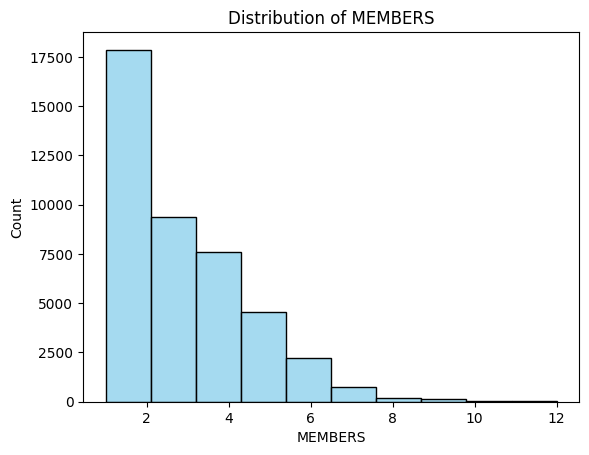

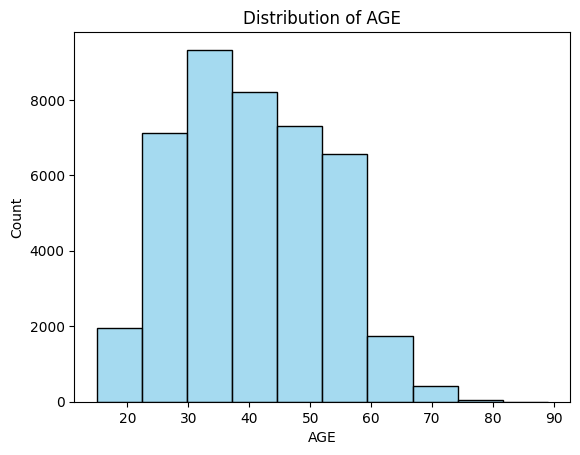

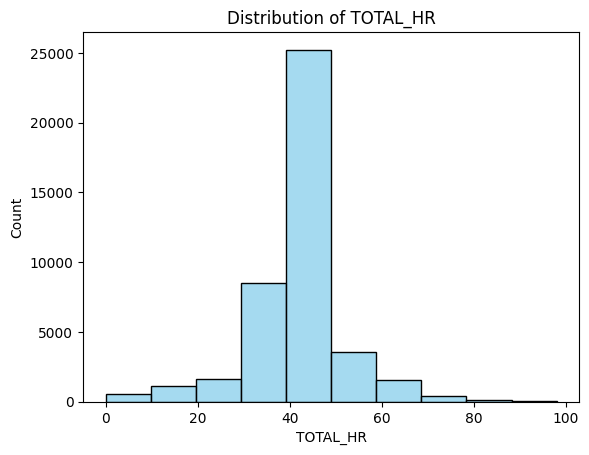

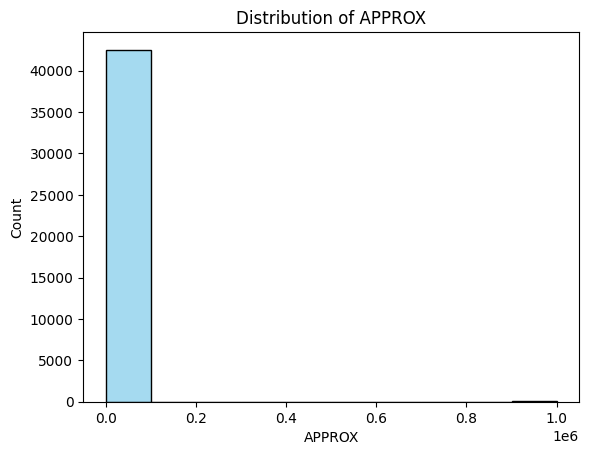

In [8]:
for col in df.select_dtypes(include="number").columns:
    plt.Figure(figsize=(10, 4))
    sns.histplot(df[col], bins=10, color="skyblue")
    plt.title(f'Distribution of {col}')
    plt.show()

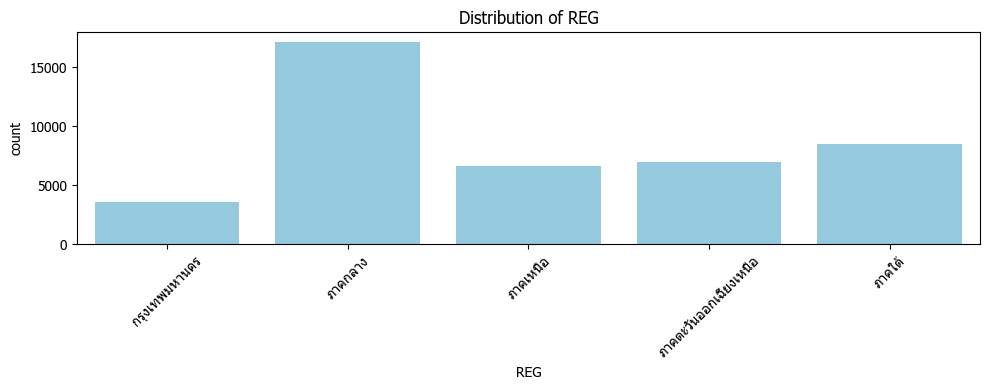

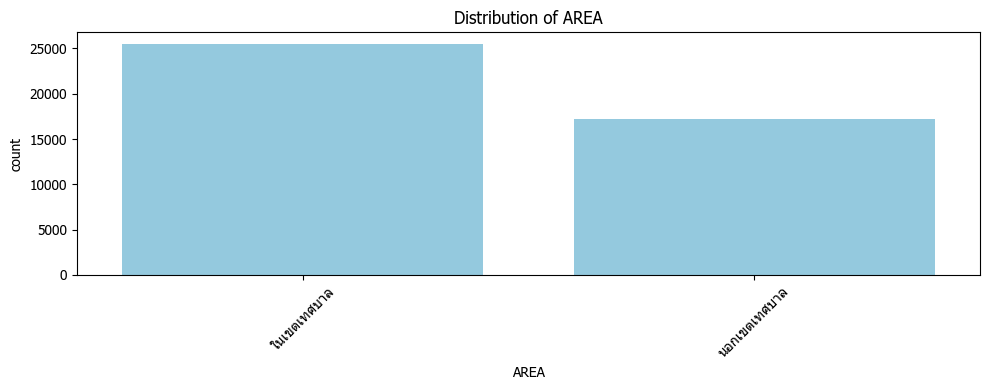

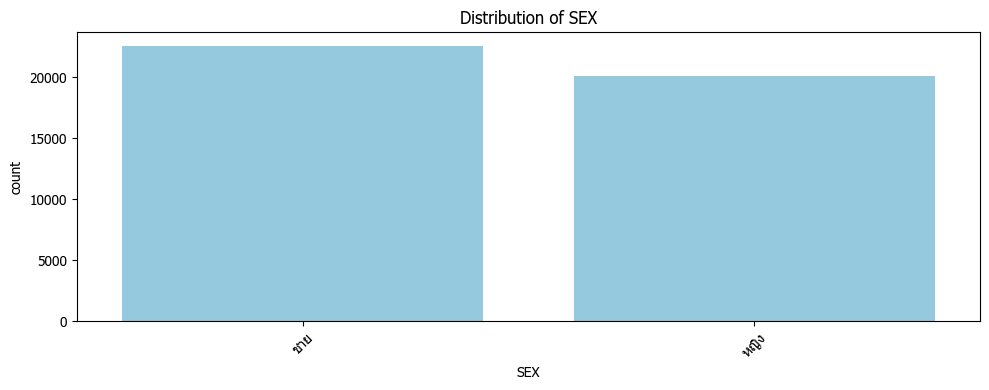

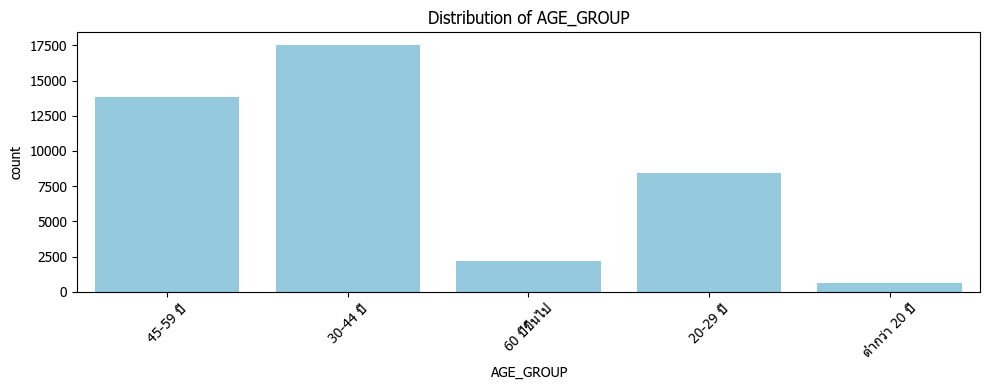

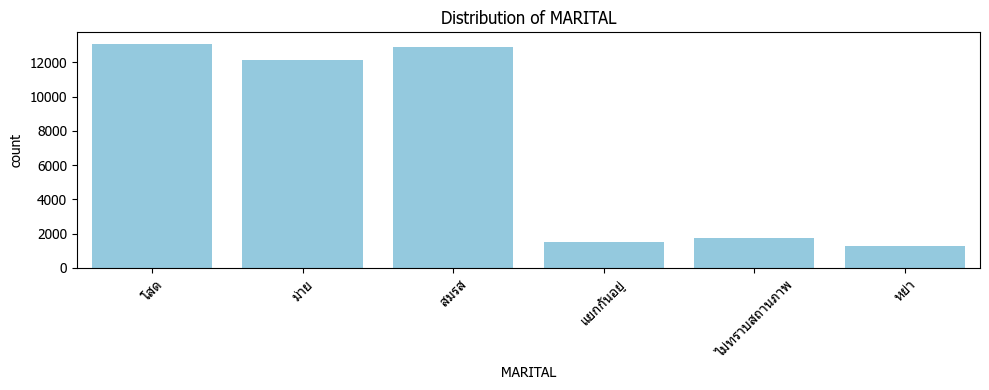

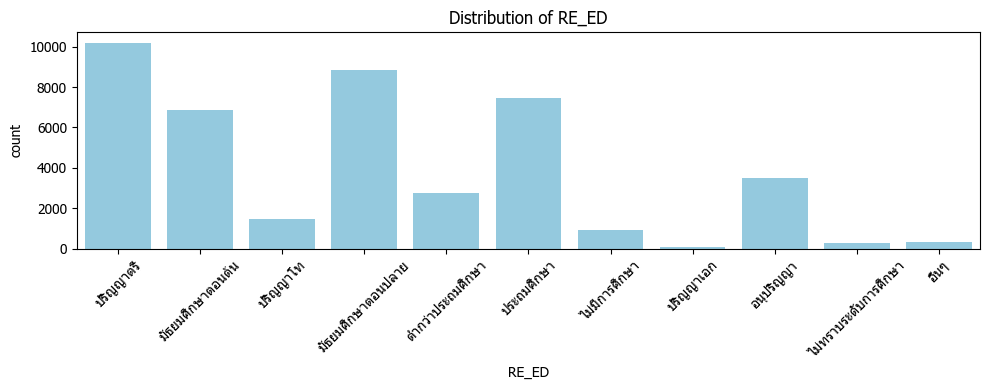

In [9]:
plt.rcParams['font.family'] = 'Tahoma'
plt.rcParams['axes.unicode_minus'] = False

for col in df.select_dtypes(include=["object", "category", "string"]).columns.drop("CWT"):
    plt.figure(figsize=(10, 4))
    sns.countplot(data=df, x=col, color="skyblue")
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [10]:
print("=========================================================")
print(" 1. สถิติเบื้องต้นของ MEMBERS แบ่งตาม REG")
print("=========================================================")
desc_stats = df.groupby('REG')['MEMBERS'].agg(['count', 'mean', 'std', 'min', 'median', 'max'])
desc_stats = desc_stats.sort_values(by='mean', ascending=False)
print(desc_stats.to_string(formatters={'mean':'{:,.2f}'.format, 'std':'{:,.2f}'.format}))
print("\n")

print("=========================================================")
print(" 2. ANOVA Table")
print("=========================================================")
model = ols('MEMBERS ~ C(REG)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

p_value = anova_table.loc['C(REG)', 'PR(>F)']
print(f"\np-value ของ ANOVA คือ: {p_value:.4f}")
print("=========================================================\n")

if p_value < 0.05:
    print("=========================================================")
    print(" 3. Post-hoc Analysis & Group Letters (Tukey HSD)")
    print("=========================================================")
    
    mc = MultiComparison(df['MEMBERS'], df['REG'])
    tukey_result = mc.tukeyhsd()
    
    print("--- ผลการเปรียบเทียบรายคู่ ---")
    print(tukey_result.summary())
    print("\n")
    
    print("--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---")
    print("เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ย 'ไม่แตกต่างกัน'")
    print("---------------------------------------------------------")
    
    means = df.groupby('REG')['MEMBERS'].mean()
    sorted_groups = means.sort_values(ascending=False).index.tolist()
    
    tukey_df = pd.DataFrame(tukey_result.summary().data[1:], columns=tukey_result.summary().data[0])
    
    adj_matrix = pd.DataFrame(False, index=sorted_groups, columns=sorted_groups)
    for _, row in tukey_df.iterrows():
        g1 = str(row['group1'])
        g2 = str(row['group2'])
        reject = bool(row['reject'])
        if g1 in sorted_groups and g2 in sorted_groups:
            adj_matrix.loc[g1, g2] = not reject
            adj_matrix.loc[g2, g1] = not reject
            
    for g in sorted_groups:
        adj_matrix.loc[g, g] = True

    clique_list = []
    for g in sorted_groups:
        connected = adj_matrix.index[adj_matrix[g]].tolist()
        for i in range(len(connected)):
            for j in range(i + 1, len(connected)):
                if not adj_matrix.loc[connected[i], connected[j]]:
                    connected.remove(connected[j])
                    break
        clique = sorted(list(set(connected)))
        if clique not in clique_list:
            clique_list.append(clique)

    for i in range(len(clique_list)-1, -1, -1):
        for j in range(len(clique_list)):
            if i != j and set(clique_list[i]).issubset(set(clique_list[j])):
                clique_list.pop(i)
                break

    clique_list.sort(key=lambda x: [sorted_groups.index(item) for item in x])

    letters = {g: "" for g in sorted_groups}
    for idx, clique in enumerate(clique_list):
        letter = chr(ord('a') + idx)
        for g in clique:
            letters[g] += letter

    rank_summary = df.groupby('REG')['MEMBERS'].mean().reset_index()
    rank_summary['REG_STR'] = rank_summary['REG'].astype(str)
    rank_summary['Group Sign'] = rank_summary['REG_STR'].map(letters)
    rank_summary = rank_summary.sort_values(by='MEMBERS', ascending=False).reset_index(drop=True)
    rank_summary.index = rank_summary.index + 1
    rank_summary.index.name = 'Rank (Mean มากสุด)'
    
    rank_summary = rank_summary[['REG', 'MEMBERS', 'Group Sign']]
    rank_summary.columns = ['Region (REG)', 'Mean MEMBERS', 'Statistical Group']
    
    print(rank_summary.to_string(formatters={'Mean MEMBERS':'{:,.4f}'.format}))
    print("---------------------------------------------------------")

else:
    print("ผลการทดสอบ ANOVA ไม่มีนัยสำคัญทางสถิติ จึงไม่มีการทำ Post-hoc และจัดกลุ่มอันดับ")

 1. สถิติเบื้องต้นของ MEMBERS แบ่งตาม REG
                       count mean  std  min  median  max
REG                                                     
ภาคใต้                  8479 3.32 1.66    1     3.0   11
ภาคตะวันออกเฉียงเหนือ   6953 3.22 1.58    1     3.0   10
ภาคเหนือ                6625 3.13 1.49    1     3.0   11
ภาคกลาง                17083 3.00 1.63    1     3.0   12
กรุงเทพมหานคร           3542 2.47 1.40    1     2.0    9


 2. ANOVA Table
                 sum_sq       df           F         PR(>F)
C(REG)      2050.819552      4.0  203.609728  2.605487e-173
Residual  107463.954194  42677.0         NaN            NaN

p-value ของ ANOVA คือ: 0.0000

 3. Post-hoc Analysis & Group Letters (Tukey HSD)
--- ผลการเปรียบเทียบรายคู่ ---
               Multiple Comparison of Means - Tukey HSD, FWER=0.05                
        group1                group2        meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------------------

In [11]:
print("=========================================================")
print(" 1. สถิติเบื้องต้นของ MEMBERS แบ่งตาม MARITAL")
print("=========================================================")
desc_stats = df.groupby('MARITAL')['MEMBERS'].agg(['count', 'mean', 'std', 'min', 'median', 'max'])
desc_stats = desc_stats.sort_values(by='mean', ascending=False)
print(desc_stats.to_string(formatters={'mean':'{:,.2f}'.format, 'std':'{:,.2f}'.format}))
print("\n")

print("=========================================================")
print(" 2. ANOVA Table")
print("=========================================================")
model = ols('MEMBERS ~ C(MARITAL)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

p_value = anova_table.loc['C(MARITAL)', 'PR(>F)']
print(f"\np-value ของ ANOVA คือ: {p_value:.4f}")
print("=========================================================\n")

if p_value < 0.05:
    print("=========================================================")
    print(" 3. Post-hoc Analysis & Group Letters (Tukey HSD)")
    print("=========================================================")
    
    mc = MultiComparison(df['MEMBERS'], df['MARITAL'])
    tukey_result = mc.tukeyhsd()
    
    print("--- ผลการเปรียบเทียบรายคู่ ---")
    print(tukey_result.summary())
    print("\n")
    
    print("--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---")
    print("เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ย 'ไม่แตกต่างกัน'")
    print("---------------------------------------------------------")
    
    means = df.groupby('MARITAL')['MEMBERS'].mean()
    sorted_groups = means.sort_values(ascending=False).index.tolist()
    
    tukey_df = pd.DataFrame(tukey_result.summary().data[1:], columns=tukey_result.summary().data[0])
    
    adj_matrix = pd.DataFrame(False, index=sorted_groups, columns=sorted_groups)
    for _, row in tukey_df.iterrows():
        g1 = str(row['group1'])
        g2 = str(row['group2'])
        reject = bool(row['reject'])
        if g1 in sorted_groups and g2 in sorted_groups:
            adj_matrix.loc[g1, g2] = not reject
            adj_matrix.loc[g2, g1] = not reject
            
    for g in sorted_groups:
        adj_matrix.loc[g, g] = True

    clique_list = []
    for g in sorted_groups:
        connected = adj_matrix.index[adj_matrix[g]].tolist()
        for i in range(len(connected)):
            for j in range(i + 1, len(connected)):
                if not adj_matrix.loc[connected[i], connected[j]]:
                    connected.remove(connected[j])
                    break
        clique = sorted(list(set(connected)))
        if clique not in clique_list:
            clique_list.append(clique)

    for i in range(len(clique_list)-1, -1, -1):
        for j in range(len(clique_list)):
            if i != j and set(clique_list[i]).issubset(set(clique_list[j])):
                clique_list.pop(i)
                break

    clique_list.sort(key=lambda x: [sorted_groups.index(item) for item in x])

    letters = {g: "" for g in sorted_groups}
    for idx, clique in enumerate(clique_list):
        letter = chr(ord('a') + idx)
        for g in clique:
            letters[g] += letter

    rank_summary = df.groupby('MARITAL')['MEMBERS'].mean().reset_index()
    rank_summary['MARITAL_STR'] = rank_summary['MARITAL'].astype(str)
    rank_summary['Group Sign'] = rank_summary['MARITAL_STR'].map(letters)
    rank_summary = rank_summary.sort_values(by='MEMBERS', ascending=False).reset_index(drop=True)
    rank_summary.index = rank_summary.index + 1
    rank_summary.index.name = 'Rank (Mean มากสุด)'
    
    rank_summary = rank_summary[['MARITAL', 'MEMBERS', 'Group Sign']]
    rank_summary.columns = ['Marital Status (MARITAL)', 'Mean MEMBERS', 'Statistical Group']
    
    print(rank_summary.to_string(formatters={'Mean MEMBERS':'{:,.4f}'.format}))
    print("---------------------------------------------------------")

else:
    print("ผลการทดสอบ ANOVA ไม่มีนัยสำคัญทางสถิติ จึงไม่มีการทำ Post-hoc และจัดกลุ่มอันดับ")

 1. สถิติเบื้องต้นของ MEMBERS แบ่งตาม MARITAL
                count mean  std  min  median  max
MARITAL                                          
ม่าย            12153 3.41 1.59    1     3.0   12
สมรส            12893 3.37 1.49    1     3.0   11
ไม่ทราบสถานภาพ   1777 2.84 1.71    1     3.0   10
แยกกันอยู่       1492 2.76 1.63    1     2.0    9
โสด             13099 2.61 1.58    1     2.0   12
หย่า             1268 2.48 1.46    1     2.0    8


 2. ANOVA Table
                   sum_sq       df           F  PR(>F)
C(MARITAL)    5974.005629      5.0  492.456583     0.0
Residual    103540.768116  42676.0         NaN     NaN

p-value ของ ANOVA คือ: 0.0000

 3. Post-hoc Analysis & Group Letters (Tukey HSD)
--- ผลการเปรียบเทียบรายคู่ ---
      Multiple Comparison of Means - Tukey HSD, FWER=0.05       
  group1       group2     meandiff p-adj   lower   upper  reject
----------------------------------------------------------------
      ม่าย           สมรส  -0.0374 0.4027 -0.0935  0.0187  Fals

In [12]:
print("=========================================================")
print(" 1. สถิติเบื้องต้นของ MEMBERS แบ่งตาม AGE_GROUP")
print("=========================================================")
desc_stats = df.groupby('AGE_GROUP')['MEMBERS'].agg(['count', 'mean', 'std', 'min', 'median', 'max'])
desc_stats = desc_stats.sort_values(by='mean', ascending=False)
print(desc_stats.to_string(formatters={'mean':'{:,.2f}'.format, 'std':'{:,.2f}'.format}))
print("\n")

print("=========================================================")
print(" 2. ANOVA Table")
print("=========================================================")
model = ols('MEMBERS ~ C(AGE_GROUP)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

p_value = anova_table.loc['C(AGE_GROUP)', 'PR(>F)']
print(f"\np-value ของ ANOVA คือ: {p_value:.4f}")
print("=========================================================\n")

if p_value < 0.05:
    print("=========================================================")
    print(" 3. Post-hoc Analysis & Group Letters (Tukey HSD)")
    print("=========================================================")
    
    mc = MultiComparison(df['MEMBERS'], df['AGE_GROUP'])
    tukey_result = mc.tukeyhsd()
    
    print("--- ผลการเปรียบเทียบรายคู่ ---")
    print(tukey_result.summary())
    print("\n")
    
    print("--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---")
    print("เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ย 'ไม่แตกต่างกัน'")
    print("---------------------------------------------------------")
    
    means = df.groupby('AGE_GROUP')['MEMBERS'].mean()
    sorted_groups = means.sort_values(ascending=False).index.tolist()
    
    tukey_df = pd.DataFrame(tukey_result.summary().data[1:], columns=tukey_result.summary().data[0])
    
    adj_matrix = pd.DataFrame(False, index=sorted_groups, columns=sorted_groups)
    for _, row in tukey_df.iterrows():
        g1 = str(row['group1'])
        g2 = str(row['group2'])
        reject = bool(row['reject'])
        if g1 in sorted_groups and g2 in sorted_groups:
            adj_matrix.loc[g1, g2] = not reject
            adj_matrix.loc[g2, g1] = not reject
            
    for g in sorted_groups:
        adj_matrix.loc[g, g] = True

    clique_list = []
    for g in sorted_groups:
        connected = adj_matrix.index[adj_matrix[g]].tolist()
        for i in range(len(connected)):
            for j in range(i + 1, len(connected)):
                if not adj_matrix.loc[connected[i], connected[j]]:
                    connected.remove(connected[j])
                    break
        clique = sorted(list(set(connected)))
        if clique not in clique_list:
            clique_list.append(clique)

    for i in range(len(clique_list)-1, -1, -1):
        for j in range(len(clique_list)):
            if i != j and set(clique_list[i]).issubset(set(clique_list[j])):
                clique_list.pop(i)
                break

    clique_list.sort(key=lambda x: [sorted_groups.index(item) for item in x])

    letters = {g: "" for g in sorted_groups}
    for idx, clique in enumerate(clique_list):
        letter = chr(ord('a') + idx)
        for g in clique:
            letters[g] += letter

    rank_summary = df.groupby('AGE_GROUP')['MEMBERS'].mean().reset_index()
    rank_summary['AGE_GROUP_STR'] = rank_summary['AGE_GROUP'].astype(str)
    rank_summary['Group Sign'] = rank_summary['AGE_GROUP_STR'].map(letters)
    rank_summary = rank_summary.sort_values(by='MEMBERS', ascending=False).reset_index(drop=True)
    rank_summary.index = rank_summary.index + 1
    rank_summary.index.name = 'Rank (Mean มากสุด)'
    
    rank_summary = rank_summary[['AGE_GROUP', 'MEMBERS', 'Group Sign']]
    rank_summary.columns = ['Age Group (AGE_GROUP)', 'Mean MEMBERS', 'Statistical Group']
    
    print(rank_summary.to_string(formatters={'Mean MEMBERS':'{:,.4f}'.format}))
    print("---------------------------------------------------------")

else:
    print("ผลการทดสอบ ANOVA ไม่มีนัยสำคัญทางสถิติ จึงไม่มีการทำ Post-hoc และจัดกลุ่มอันดับ")

 1. สถิติเบื้องต้นของ MEMBERS แบ่งตาม AGE_GROUP
               count mean  std  min  median  max
AGE_GROUP                                       
ต่ำกว่า 20 ปี    605 3.80 1.68    1     4.0   10
20-29 ปี        8454 3.27 1.70    1     3.0   12
30-44 ปี       17546 3.15 1.65    1     3.0   12
60 ปีขึ้นไป     2212 2.88 1.54    1     3.0   10
45-59 ปี       13865 2.87 1.44    1     3.0   12


 2. ANOVA Table
                     sum_sq       df           F         PR(>F)
C(AGE_GROUP)    1368.014388      4.0  134.961857  8.635121e-115
Residual      108146.759357  42677.0         NaN            NaN

p-value ของ ANOVA คือ: 0.0000

 3. Post-hoc Analysis & Group Letters (Tukey HSD)
--- ผลการเปรียบเทียบรายคู่ ---
      Multiple Comparison of Means - Tukey HSD, FWER=0.05       
   group1       group2    meandiff p-adj   lower   upper  reject
----------------------------------------------------------------
   20-29 ปี      30-44 ปี  -0.1192    0.0 -0.1767 -0.0617   True
   20-29 ปี      45-59 ปี 

In [13]:
print("=========================================================")
print(" 1. สถิติเบื้องต้นของ MEMBERS แบ่งตาม RE_ED")
print("=========================================================")
desc_stats = df.groupby('RE_ED')['MEMBERS'].agg(['count', 'mean', 'std', 'min', 'median', 'max'])
desc_stats = desc_stats.sort_values(by='mean', ascending=False)
print(desc_stats.to_string(formatters={'mean':'{:,.2f}'.format, 'std':'{:,.2f}'.format}))
print("\n")

print("=========================================================")
print(" 2. ANOVA Table")
print("=========================================================")
model = ols('MEMBERS ~ C(RE_ED)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

p_value = anova_table.loc['C(RE_ED)', 'PR(>F)']
print(f"\np-value ของ ANOVA คือ: {p_value:.4f}")
print("=========================================================\n")

if p_value < 0.05:
    print("=========================================================")
    print(" 3. Post-hoc Analysis & Group Letters (Tukey HSD)")
    print("=========================================================")
    
    mc = MultiComparison(df['MEMBERS'], df['RE_ED'])
    tukey_result = mc.tukeyhsd()
    
    print("--- ผลการเปรียบเทียบรายคู่ ---")
    print(tukey_result.summary())
    print("\n")
    
    print("--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---")
    print("เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ย 'ไม่แตกต่างกัน'")
    print("---------------------------------------------------------")
    
    means = df.groupby('RE_ED')['MEMBERS'].mean()
    sorted_groups = means.sort_values(ascending=False).index.tolist()
    
    tukey_df = pd.DataFrame(tukey_result.summary().data[1:], columns=tukey_result.summary().data[0])
    
    adj_matrix = pd.DataFrame(False, index=sorted_groups, columns=sorted_groups)
    for _, row in tukey_df.iterrows():
        g1 = str(row['group1'])
        g2 = str(row['group2'])
        reject = bool(row['reject'])
        if g1 in sorted_groups and g2 in sorted_groups:
            adj_matrix.loc[g1, g2] = not reject
            adj_matrix.loc[g2, g1] = not reject
            
    for g in sorted_groups:
        adj_matrix.loc[g, g] = True

    clique_list = []
    for g in sorted_groups:
        connected = adj_matrix.index[adj_matrix[g]].tolist()
        for i in range(len(connected)):
            for j in range(i + 1, len(connected)):
                if not adj_matrix.loc[connected[i], connected[j]]:
                    connected.remove(connected[j])
                    break
        clique = sorted(list(set(connected)))
        if clique not in clique_list:
            clique_list.append(clique)

    for i in range(len(clique_list)-1, -1, -1):
        for j in range(len(clique_list)):
            if i != j and set(clique_list[i]).issubset(set(clique_list[j])):
                clique_list.pop(i)
                break

    clique_list.sort(key=lambda x: [sorted_groups.index(item) for item in x])

    letters = {g: "" for g in sorted_groups}
    for idx, clique in enumerate(clique_list):
        letter = chr(ord('a') + idx)
        for g in clique:
            letters[g] += letter

    rank_summary = df.groupby('RE_ED')['MEMBERS'].mean().reset_index()
    rank_summary['RE_ED_STR'] = rank_summary['RE_ED'].astype(str)
    rank_summary['Group Sign'] = rank_summary['RE_ED_STR'].map(letters)
    rank_summary = rank_summary.sort_values(by='MEMBERS', ascending=False).reset_index(drop=True)
    rank_summary.index = rank_summary.index + 1
    rank_summary.index.name = 'Rank (Mean มากสุด)'
    
    rank_summary = rank_summary[['RE_ED', 'MEMBERS', 'Group Sign']]
    rank_summary.columns = ['Education Level (RE_ED)', 'Mean MEMBERS', 'Statistical Group']
    
    print(rank_summary.to_string(formatters={'Mean MEMBERS':'{:,.4f}'.format}))
    print("---------------------------------------------------------")

else:
    print("ผลการทดสอบ ANOVA ไม่มีนัยสำคัญทางสถิติ จึงไม่มีการทำ Post-hoc และจัดกลุ่มอันดับ")

 1. สถิติเบื้องต้นของ MEMBERS แบ่งตาม RE_ED
                      count mean  std  min  median  max
RE_ED                                                  
มัธยมศึกษาตอนต้น       6871 3.25 1.69    1     3.0   12
มัธยมศึกษาตอนปลาย      8859 3.15 1.65    1     3.0   11
อนุปริญญา              3493 3.14 1.59    1     3.0   11
ประถมศึกษา             7436 3.11 1.61    1     3.0   12
ปริญญาเอก                67 3.09 1.52    1     3.0    7
ปริญญาตรี             10196 3.00 1.53    1     3.0   11
ต่ำกว่าประถมศึกษา      2769 2.97 1.58    1     3.0   11
ปริญญาโท               1455 2.88 1.43    1     3.0    9
ไม่มีการศึกษา           919 2.77 1.46    1     2.0   10
อื่นๆ                   346 2.13 0.91    1     2.0    7
ไม่ทราบระดับการศึกษา    271 2.03 1.36    1     2.0    8


 2. ANOVA Table
                 sum_sq       df          F        PR(>F)
C(RE_ED)    1105.171444     10.0  43.500548  9.511545e-87
Residual  108409.602301  42671.0        NaN           NaN

p-value ของ ANOVA คือ: 0.0000

 3. 

In [14]:
print("=========================================================")
print(" 1. สถิติเบื้องต้นของ MEMBERS แบ่งตาม AREA")
print("=========================================================")
desc_stats = df.groupby('AREA')['MEMBERS'].agg(['count', 'mean', 'std', 'min', 'median', 'max'])
desc_stats = desc_stats.sort_values(by='mean', ascending=False)
print(desc_stats.to_string(formatters={'mean':'{:,.2f}'.format, 'std':'{:,.2f}'.format}))
print("\n")

print("=========================================================")
print(" 2. Two-Sample Z-Test Table")
print("=========================================================")
groups = desc_stats.index.tolist()

if len(groups) == 2:
    g1, g2 = groups[0], groups[1]
    
    n1, mean1, std1 = desc_stats.loc[g1, 'count'], desc_stats.loc[g1, 'mean'], desc_stats.loc[g1, 'std']
    n2, mean2, std2 = desc_stats.loc[g2, 'count'], desc_stats.loc[g2, 'mean'], desc_stats.loc[g2, 'std']
    
    pooled_se = np.sqrt((std1**2 / n1) + (std2**2 / n2))
    z_stat = (mean1 - mean2) / pooled_se
    p_value = 2 * (1 - stats.norm.cdf(np.abs(z_stat)))
    
    z_table = pd.DataFrame({
        'Comparison': [f"{g1} vs {g2}"],
        'Z-statistic': [z_stat],
        'P-value': [p_value]
    })
    print(z_table.to_string(index=False, formatters={'Z-statistic':'{:,.4f}'.format, 'P-value':'{:,.4f}'.format}))
    print(f"\np-value ของ Z-Test คือ: {p_value:.4f}")
    print("=========================================================\n")
    
    if p_value < 0.05:
        print("=========================================================")
        print(" 3. Group Letters (Z-Test)")
        print("=========================================================")
        print("--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---")
        print("เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ย 'ไม่แตกต่างกัน'")
        print("---------------------------------------------------------")
        
        rank_summary = pd.DataFrame({
            'Area Type (AREA)': [g1, g2],
            'Mean MEMBERS': [mean1, mean2],
            'Statistical Group': ['a', 'b']
        })
        rank_summary.index = [1, 2]
        rank_summary.index.name = 'Rank (Mean มากสุด)'
        print(rank_summary.to_string(formatters={'Mean MEMBERS':'{:,.4f}'.format}))
        print("---------------------------------------------------------")
    else:
        print("=========================================================")
        print(" 3. Group Letters (Z-Test)")
        print("=========================================================")
        print("--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---")
        print("เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ย 'ไม่แตกต่างกัน'")
        print("---------------------------------------------------------")
        
        rank_summary = pd.DataFrame({
            'Area Type (AREA)': [g1, g2],
            'Mean MEMBERS': [mean1, mean2],
            'Statistical Group': ['a', 'a']
        })
        rank_summary.index = [1, 2]
        rank_summary.index.name = 'Rank (Mean มากสุด)'
        print(rank_summary.to_string(formatters={'Mean MEMBERS':'{:,.4f}'.format}))
        print("---------------------------------------------------------")
else:
    print(f"ข้อผิดพลาด: ข้อมูลกลุ่ม AREA มีจำนวน {len(groups)} กลุ่ม (Z-Test รองรับการเปรียบเทียบ 2 กลุ่มเท่านั้น)")

 1. สถิติเบื้องต้นของ MEMBERS แบ่งตาม AREA
              count mean  std  min  median  max
AREA                                           
นอกเขตเทศบาล  17180 3.32 1.64    1     3.0   12
ในเขตเทศบาล   25502 2.92 1.55    1     3.0   12


 2. Two-Sample Z-Test Table
                 Comparison Z-statistic P-value
นอกเขตเทศบาล vs ในเขตเทศบาล     25.4437  0.0000

p-value ของ Z-Test คือ: 0.0000

 3. Group Letters (Z-Test)
--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---
เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ย 'ไม่แตกต่างกัน'
---------------------------------------------------------
                   Area Type (AREA) Mean MEMBERS Statistical Group
Rank (Mean มากสุด)                                                
1                      นอกเขตเทศบาล       3.3185                 a
2                       ในเขตเทศบาล       2.9151                 b
---------------------------------------------------------


In [15]:
print("=========================================================")
print(" 1. สถิติเบื้องต้นของ MEMBERS แบ่งตาม SEX")
print("=========================================================")
desc_stats = df.groupby('SEX')['MEMBERS'].agg(['count', 'mean', 'std', 'min', 'median', 'max'])
desc_stats = desc_stats.sort_values(by='mean', ascending=False)
print(desc_stats.to_string(formatters={'mean':'{:,.2f}'.format, 'std':'{:,.2f}'.format}))
print("\n")

print("=========================================================")
print(" 2. Two-Sample Z-Test Table")
print("=========================================================")
groups = desc_stats.index.tolist()

if len(groups) == 2:
    g1, g2 = groups[0], groups[1]
    
    n1, mean1, std1 = desc_stats.loc[g1, 'count'], desc_stats.loc[g1, 'mean'], desc_stats.loc[g1, 'std']
    n2, mean2, std2 = desc_stats.loc[g2, 'count'], desc_stats.loc[g2, 'mean'], desc_stats.loc[g2, 'std']
    
    pooled_se = np.sqrt((std1**2 / n1) + (std2**2 / n2))
    z_stat = (mean1 - mean2) / pooled_se
    p_value = 2 * (1 - stats.norm.cdf(np.abs(z_stat)))
    
    z_table = pd.DataFrame({
        'Comparison': [f"{g1} vs {g2}"],
        'Z-statistic': [z_stat],
        'P-value': [p_value]
    })
    print(z_table.to_string(index=False, formatters={'Z-statistic':'{:,.4f}'.format, 'P-value':'{:,.4f}'.format}))
    print(f"\np-value ของ Z-Test คือ: {p_value:.4f}")
    print("=========================================================\n")
    
    if p_value < 0.05:
        print("=========================================================")
        print(" 3. Group Letters (Z-Test)")
        print("=========================================================")
        print("--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---")
        print("เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ย 'ไม่แตกต่างกัน'")
        print("---------------------------------------------------------")
        
        rank_summary = pd.DataFrame({
            'Gender (SEX)': [g1, g2],
            'Mean MEMBERS': [mean1, mean2],
            'Statistical Group': ['a', 'b']
        })
        rank_summary.index = [1, 2]
        rank_summary.index.name = 'Rank (Mean มากสุด)'
        print(rank_summary.to_string(formatters={'Mean MEMBERS':'{:,.4f}'.format}))
        print("---------------------------------------------------------")
    else:
        print("=========================================================")
        print(" 3. Group Letters (Z-Test)")
        print("=========================================================")
        print("--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---")
        print("เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ย 'ไม่แตกต่างกัน'")
        print("---------------------------------------------------------")
        
        rank_summary = pd.DataFrame({
            'Gender (SEX)': [g1, g2],
            'Mean MEMBERS': [mean1, mean2],
            'Statistical Group': ['a', 'a']
        })
        rank_summary.index = [1, 2]
        rank_summary.index.name = 'Rank (Mean มากสุด)'
        print(rank_summary.to_string(formatters={'Mean MEMBERS':'{:,.4f}'.format}))
        print("---------------------------------------------------------")
else:
    print(f"ข้อผิดพลาด: ข้อมูลกลุ่ม SEX มีจำนวน {len(groups)} กลุ่ม (Z-Test รองรับการเปรียบเทียบ 2 กลุ่มเท่านั้น)")

 1. สถิติเบื้องต้นของ MEMBERS แบ่งตาม SEX
      count mean  std  min  median  max
SEX                                    
ชาย   22569 3.08 1.62    1     3.0   12
หญิง  20113 3.08 1.58    1     3.0   12


 2. Two-Sample Z-Test Table
 Comparison Z-statistic P-value
ชาย vs หญิง      0.0567  0.9548

p-value ของ Z-Test คือ: 0.9548

 3. Group Letters (Z-Test)
--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---
เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ย 'ไม่แตกต่างกัน'
---------------------------------------------------------
                   Gender (SEX) Mean MEMBERS Statistical Group
Rank (Mean มากสุด)                                            
1                           ชาย       3.0779                 a
2                          หญิง       3.0770                 a
---------------------------------------------------------


In [16]:
print("=========================================================")
print(" 1. สถิติเบื้องต้นของ AGE แบ่งตาม REG")
print("=========================================================")
desc_stats = df.groupby('REG')['AGE'].agg(['count', 'mean', 'std', 'min', 'median', 'max'])
desc_stats = desc_stats.sort_values(by='mean', ascending=False)
print(desc_stats.to_string(formatters={'mean':'{:,.2f}'.format, 'std':'{:,.2f}'.format}))
print("\n")

print("=========================================================")
print(" 2. ANOVA Table")
print("=========================================================")
model = ols('AGE ~ C(REG)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

p_value = anova_table.loc['C(REG)', 'PR(>F)']
print(f"\np-value ของ ANOVA คือ: {p_value:.4f}")
print("=========================================================\n")

if p_value < 0.05:
    print("=========================================================")
    print(" 3. Post-hoc Analysis & Group Letters (Tukey HSD)")
    print("=========================================================")
    
    mc = MultiComparison(df['AGE'], df['REG'])
    tukey_result = mc.tukeyhsd()
    
    print("--- ผลการเปรียบเทียบรายคู่ ---")
    print(tukey_result.summary())
    print("\n")
    
    print("--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---")
    print("เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ย 'ไม่แตกต่างกัน'")
    print("---------------------------------------------------------")
    
    means = df.groupby('REG')['AGE'].mean()
    sorted_groups = means.sort_values(ascending=False).index.tolist()
    
    tukey_df = pd.DataFrame(tukey_result.summary().data[1:], columns=tukey_result.summary().data[0])
    
    adj_matrix = pd.DataFrame(False, index=sorted_groups, columns=sorted_groups)
    for _, row in tukey_df.iterrows():
        g1 = str(row['group1'])
        g2 = str(row['group2'])
        reject = bool(row['reject'])
        if g1 in sorted_groups and g2 in sorted_groups:
            adj_matrix.loc[g1, g2] = not reject
            adj_matrix.loc[g2, g1] = not reject
            
    for g in sorted_groups:
        adj_matrix.loc[g, g] = True

    clique_list = []
    for g in sorted_groups:
        connected = adj_matrix.index[adj_matrix[g]].tolist()
        for i in range(len(connected)):
            for j in range(i + 1, len(connected)):
                if not adj_matrix.loc[connected[i], connected[j]]:
                    connected.remove(connected[j])
                    break
        clique = sorted(list(set(connected)))
        if clique not in clique_list:
            clique_list.append(clique)

    for i in range(len(clique_list)-1, -1, -1):
        for j in range(len(clique_list)):
            if i != j and set(clique_list[i]).issubset(set(clique_list[j])):
                clique_list.pop(i)
                break

    clique_list.sort(key=lambda x: [sorted_groups.index(item) for item in x])

    letters = {g: "" for g in sorted_groups}
    for idx, clique in enumerate(clique_list):
        letter = chr(ord('a') + idx)
        for g in clique:
            letters[g] += letter

    rank_summary = df.groupby('REG')['AGE'].mean().reset_index()
    rank_summary['REG_STR'] = rank_summary['REG'].astype(str)
    rank_summary['Group Sign'] = rank_summary['REG_STR'].map(letters)
    rank_summary = rank_summary.sort_values(by='AGE', ascending=False).reset_index(drop=True)
    rank_summary.index = rank_summary.index + 1
    rank_summary.index.name = 'Rank (Mean มากสุด)'
    
    rank_summary = rank_summary[['REG', 'AGE', 'Group Sign']]
    rank_summary.columns = ['Region (REG)', 'Mean AGE', 'Statistical Group']
    
    print(rank_summary.to_string(formatters={'Mean AGE':'{:,.4f}'.format}))
    print("---------------------------------------------------------")

else:
    print("ผลการทดสอบ ANOVA ไม่มีนัยสำคัญทางสถิติ จึงไม่มีการทำ Post-hoc และจัดกลุ่มอันดับ")

 1. สถิติเบื้องต้นของ AGE แบ่งตาม REG
                       count  mean   std  min  median  max
REG                                                       
ภาคเหนือ                6625 41.97 12.10   15    42.0   85
ภาคตะวันออกเฉียงเหนือ   6953 41.96 11.51   15    42.0   78
ภาคกลาง                17083 40.00 11.80   15    39.0   89
ภาคใต้                  8479 39.55 11.78   15    39.0   82
กรุงเทพมหานคร           3542 39.22 11.69   16    38.0   81


 2. ANOVA Table
                sum_sq       df          F        PR(>F)
C(REG)    4.667117e+04      4.0  83.974178  3.722780e-71
Residual  5.929756e+06  42677.0        NaN           NaN

p-value ของ ANOVA คือ: 0.0000

 3. Post-hoc Analysis & Group Letters (Tukey HSD)
--- ผลการเปรียบเทียบรายคู่ ---
               Multiple Comparison of Means - Tukey HSD, FWER=0.05                
        group1                group2        meandiff p-adj   lower   upper  reject
---------------------------------------------------------------------------------

In [17]:
print("=========================================================")
print(" 1. สถิติเบื้องต้นของ AGE แบ่งตาม MARITAL")
print("=========================================================")
desc_stats = df.groupby('MARITAL')['AGE'].agg(['count', 'mean', 'std', 'min', 'median', 'max'])
desc_stats = desc_stats.sort_values(by='mean', ascending=False)
print(desc_stats.to_string(formatters={'mean':'{:,.2f}'.format, 'std':'{:,.2f}'.format}))
print("\n")

print("=========================================================")
print(" 2. ANOVA Table")
print("=========================================================")
model = ols('AGE ~ C(MARITAL)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

p_value = anova_table.loc['C(MARITAL)', 'PR(>F)']
print(f"\np-value ของ ANOVA คือ: {p_value:.4f}")
print("=========================================================\n")

if p_value < 0.05:
    print("=========================================================")
    print(" 3. Post-hoc Analysis & Group Letters (Tukey HSD)")
    print("=========================================================")
    
    mc = MultiComparison(df['AGE'], df['MARITAL'])
    tukey_result = mc.tukeyhsd()
    
    print("--- ผลการเปรียบเทียบรายคู่ ---")
    print(tukey_result.summary())
    print("\n")
    
    print("--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---")
    print("เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ย 'ไม่แตกต่างกัน'")
    print("---------------------------------------------------------")
    
    means = df.groupby('MARITAL')['AGE'].mean()
    sorted_groups = means.sort_values(ascending=False).index.tolist()
    
    tukey_df = pd.DataFrame(tukey_result.summary().data[1:], columns=tukey_result.summary().data[0])
    
    adj_matrix = pd.DataFrame(False, index=sorted_groups, columns=sorted_groups)
    for _, row in tukey_df.iterrows():
        g1 = str(row['group1'])
        g2 = str(row['group2'])
        reject = bool(row['reject'])
        if g1 in sorted_groups and g2 in sorted_groups:
            adj_matrix.loc[g1, g2] = not reject
            adj_matrix.loc[g2, g1] = not reject
            
    for g in sorted_groups:
        adj_matrix.loc[g, g] = True

    clique_list = []
    for g in sorted_groups:
        connected = adj_matrix.index[adj_matrix[g]].tolist()
        for i in range(len(connected)):
            for j in range(i + 1, len(connected)):
                if not adj_matrix.loc[connected[i], connected[j]]:
                    connected.remove(connected[j])
                    break
        clique = sorted(list(set(connected)))
        if clique not in clique_list:
            clique_list.append(clique)

    for i in range(len(clique_list)-1, -1, -1):
        for j in range(len(clique_list)):
            if i != j and set(clique_list[i]).issubset(set(clique_list[j])):
                clique_list.pop(i)
                break

    clique_list.sort(key=lambda x: [sorted_groups.index(item) for item in x])

    letters = {g: "" for g in sorted_groups}
    for idx, clique in enumerate(clique_list):
        letter = chr(ord('a') + idx)
        for g in clique:
            letters[g] += letter

    rank_summary = df.groupby('MARITAL')['AGE'].mean().reset_index()
    rank_summary['MARITAL_STR'] = rank_summary['MARITAL'].astype(str)
    rank_summary['Group Sign'] = rank_summary['MARITAL_STR'].map(letters)
    rank_summary = rank_summary.sort_values(by='AGE', ascending=False).reset_index(drop=True)
    rank_summary.index = rank_summary.index + 1
    rank_summary.index.name = 'Rank (Mean มากสุด)'
    
    rank_summary = rank_summary[['MARITAL', 'AGE', 'Group Sign']]
    rank_summary.columns = ['Marital Status (MARITAL)', 'Mean AGE', 'Statistical Group']
    
    print(rank_summary.to_string(formatters={'Mean AGE':'{:,.4f}'.format}))
    print("---------------------------------------------------------")

else:
    print("ผลการทดสอบ ANOVA ไม่มีนัยสำคัญทางสถิติ จึงไม่มีการทำ Post-hoc และจัดกลุ่มอันดับ")

 1. สถิติเบื้องต้นของ AGE แบ่งตาม MARITAL
                count  mean   std  min  median  max
MARITAL                                            
หย่า             1268 54.31  9.83   19    55.0   85
สมรส            12893 46.84  9.95   18    48.0   80
แยกกันอยู่       1492 45.89  9.58   19    46.0   77
ไม่ทราบสถานภาพ   1777 43.68 10.43   18    44.0   89
ม่าย            12153 38.91 10.57   15    38.0   82
โสด             13099 33.25 10.16   15    31.0   78


 2. ANOVA Table
                  sum_sq       df            F  PR(>F)
C(MARITAL)  1.540929e+06      5.0  2965.199034     0.0
Residual    4.435499e+06  42676.0          NaN     NaN

p-value ของ ANOVA คือ: 0.0000

 3. Post-hoc Analysis & Group Letters (Tukey HSD)
--- ผลการเปรียบเทียบรายคู่ ---
       Multiple Comparison of Means - Tukey HSD, FWER=0.05        
  group1       group2     meandiff p-adj   lower    upper   reject
------------------------------------------------------------------
      ม่าย           สมรส   7.9309    0.0   7

In [19]:
print("=========================================================")
print(" 1. สถิติเบื้องต้นของ AGE แบ่งตาม AREA")
print("=========================================================")
desc_stats = df.groupby('AREA')['AGE'].agg(['count', 'mean', 'std', 'min', 'median', 'max'])
desc_stats = desc_stats.sort_values(by='mean', ascending=False)
print(desc_stats.to_string(formatters={'mean':'{:,.2f}'.format, 'std':'{:,.2f}'.format}))
print("\n")

print("=========================================================")
print(" 2. Two-Sample Z-Test Table")
print("=========================================================")
groups = desc_stats.index.tolist()

if len(groups) == 2:
    g1, g2 = groups[0], groups[1]
    
    n1, mean1, std1 = desc_stats.loc[g1, 'count'], desc_stats.loc[g1, 'mean'], desc_stats.loc[g1, 'std']
    n2, mean2, std2 = desc_stats.loc[g2, 'count'], desc_stats.loc[g2, 'mean'], desc_stats.loc[g2, 'std']
    
    pooled_se = np.sqrt((std1**2 / n1) + (std2**2 / n2))
    z_stat = (mean1 - mean2) / pooled_se
    p_value = 2 * (1 - stats.norm.cdf(np.abs(z_stat)))
    
    z_table = pd.DataFrame({
        'Comparison': [f"{g1} vs {g2}"],
        'Z-statistic': [z_stat],
        'P-value': [p_value]
    })
    print(z_table.to_string(index=False, formatters={'Z-statistic':'{:,.4f}'.format, 'P-value':'{:,.4f}'.format}))
    print(f"\np-value ของ Z-Test คือ: {p_value:.4f}")
    print("=========================================================\n")
    
    if p_value < 0.05:
        print("=========================================================")
        print(" 3. Group Letters (Z-Test)")
        print("=========================================================")
        print("--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---")
        print("เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ย 'ไม่แตกต่างกัน'")
        print("---------------------------------------------------------")
        
        rank_summary = pd.DataFrame({
            'Area Type (AREA)': [g1, g2],
            'Mean AGE': [mean1, mean2],
            'Statistical Group': ['a', 'b']
        })
        rank_summary.index = [1, 2]
        rank_summary.index.name = 'Rank (Mean มากสุด)'
        print(rank_summary.to_string(formatters={'Mean AGE':'{:,.4f}'.format}))
        print("---------------------------------------------------------")
    else:
        print("=========================================================")
        print(" 3. Group Letters (Z-Test)")
        print("=========================================================")
        print("--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---")
        print("เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ย 'ไม่แตกต่างกัน'")
        print("---------------------------------------------------------")
        
        rank_summary = pd.DataFrame({
            'Area Type (AREA)': [g1, g2],
            'Mean AGE': [mean1, mean2],
            'Statistical Group': ['a', 'a']
        })
        rank_summary.index = [1, 2]
        rank_summary.index.name = 'Rank (Mean มากสุด)'
        print(rank_summary.to_string(formatters={'Mean AGE':'{:,.4f}'.format}))
        print("---------------------------------------------------------")
else:
    print(f"ข้อผิดพลาด: ข้อมูลกลุ่ม AREA มีจำนวน {len(groups)} กลุ่ม (Z-Test รองรับการเปรียบเทียบ 2 กลุ่มเท่านั้น)")

 1. สถิติเบื้องต้นของ AGE แบ่งตาม AREA
              count  mean   std  min  median  max
AREA                                             
นอกเขตเทศบาล  17180 40.59 12.04   15    40.0   89
ในเขตเทศบาล   25502 40.39 11.69   15    40.0   82


 2. Two-Sample Z-Test Table
                 Comparison Z-statistic P-value
นอกเขตเทศบาล vs ในเขตเทศบาล      1.6381  0.1014

p-value ของ Z-Test คือ: 0.1014

 3. Group Letters (Z-Test)
--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---
เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ย 'ไม่แตกต่างกัน'
---------------------------------------------------------
                   Area Type (AREA) Mean AGE Statistical Group
Rank (Mean มากสุด)                                            
1                      นอกเขตเทศบาล  40.5871                 a
2                       ในเขตเทศบาล  40.3947                 a
---------------------------------------------------------


In [20]:
print("=========================================================")
print(" 1. สถิติเบื้องต้นของ AGE แบ่งตาม SEX")
print("=========================================================")
desc_stats = df.groupby('SEX')['AGE'].agg(['count', 'mean', 'std', 'min', 'median', 'max'])
desc_stats = desc_stats.sort_values(by='mean', ascending=False)
print(desc_stats.to_string(formatters={'mean':'{:,.2f}'.format, 'std':'{:,.2f}'.format}))
print("\n")

print("=========================================================")
print(" 2. Two-Sample Z-Test Table")
print("=========================================================")
groups = desc_stats.index.tolist()

if len(groups) == 2:
    g1, g2 = groups[0], groups[1]
    
    n1, mean1, std1 = desc_stats.loc[g1, 'count'], desc_stats.loc[g1, 'mean'], desc_stats.loc[g1, 'std']
    n2, mean2, std2 = desc_stats.loc[g2, 'count'], desc_stats.loc[g2, 'mean'], desc_stats.loc[g2, 'std']
    
    pooled_se = np.sqrt((std1**2 / n1) + (std2**2 / n2))
    z_stat = (mean1 - mean2) / pooled_se
    p_value = 2 * (1 - stats.norm.cdf(np.abs(z_stat)))
    
    z_table = pd.DataFrame({
        'Comparison': [f"{g1} vs {g2}"],
        'Z-statistic': [z_stat],
        'P-value': [p_value]
    })
    print(z_table.to_string(index=False, formatters={'Z-statistic':'{:,.4f}'.format, 'P-value':'{:,.4f}'.format}))
    print(f"\np-value ของ Z-Test คือ: {p_value:.4f}")
    print("=========================================================\n")
    
    if p_value < 0.05:
        print("=========================================================")
        print(" 3. Group Letters (Z-Test)")
        print("=========================================================")
        print("--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---")
        print("เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ย 'ไม่แตกต่างกัน'")
        print("---------------------------------------------------------")
        
        rank_summary = pd.DataFrame({
            'Gender (SEX)': [g1, g2],
            'Mean AGE': [mean1, mean2],
            'Statistical Group': ['a', 'b']
        })
        rank_summary.index = [1, 2]
        rank_summary.index.name = 'Rank (Mean มากสุด)'
        print(rank_summary.to_string(formatters={'Mean AGE':'{:,.4f}'.format}))
        print("---------------------------------------------------------")
    else:
        print("=========================================================")
        print(" 3. Group Letters (Z-Test)")
        print("=========================================================")
        print("--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---")
        print("เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ย 'ไม่แตกต่างกัน'")
        print("---------------------------------------------------------")
        
        rank_summary = pd.DataFrame({
            'Gender (SEX)': [g1, g2],
            'Mean AGE': [mean1, mean2],
            'Statistical Group': ['a', 'a']
        })
        rank_summary.index = [1, 2]
        rank_summary.index.name = 'Rank (Mean มากสุด)'
        print(rank_summary.to_string(formatters={'Mean AGE':'{:,.4f}'.format}))
        print("---------------------------------------------------------")
else:
    print(f"ข้อผิดพลาด: ข้อมูลกลุ่ม SEX มีจำนวน {len(groups)} กลุ่ม (Z-Test รองรับการเปรียบเทียบ 2 กลุ่มเท่านั้น)")

 1. สถิติเบื้องต้นของ AGE แบ่งตาม SEX
      count  mean   std  min  median  max
SEX                                      
ชาย   22569 40.72 12.12   15    40.0   89
หญิง  20113 40.20 11.49   15    40.0   85


 2. Two-Sample Z-Test Table
 Comparison Z-statistic P-value
ชาย vs หญิง      4.5216  0.0000

p-value ของ Z-Test คือ: 0.0000

 3. Group Letters (Z-Test)
--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---
เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ย 'ไม่แตกต่างกัน'
---------------------------------------------------------
                   Gender (SEX) Mean AGE Statistical Group
Rank (Mean มากสุด)                                        
1                           ชาย  40.7158                 a
2                          หญิง  40.1987                 b
---------------------------------------------------------


In [21]:
print("=========================================================")
print(" 1. สถิติเบื้องต้นของ TOTAL_HR แบ่งตาม REG")
print("=========================================================")
desc_stats = df.groupby('REG')['TOTAL_HR'].agg(['count', 'mean', 'std', 'min', 'median', 'max'])
desc_stats = desc_stats.sort_values(by='mean', ascending=False)
print(desc_stats.to_string(formatters={'mean':'{:,.2f}'.format, 'std':'{:,.2f}'.format}))
print("\n")

print("=========================================================")
print(" 2. ANOVA Table")
print("=========================================================")
model = ols('TOTAL_HR ~ C(REG)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

p_value = anova_table.loc['C(REG)', 'PR(>F)']
print(f"\np-value ของ ANOVA คือ: {p_value:.4f}")
print("=========================================================\n")

if p_value < 0.05:
    print("=========================================================")
    print(" 3. Post-hoc Analysis & Group Letters (Tukey HSD)")
    print("=========================================================")
    
    mc = MultiComparison(df['TOTAL_HR'], df['REG'])
    tukey_result = mc.tukeyhsd()
    
    print("--- ผลการเปรียบเทียบรายคู่ ---")
    print(tukey_result.summary())
    print("\n")
    
    print("--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---")
    print("เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ย 'ไม่แตกต่างกัน'")
    print("---------------------------------------------------------")
    
    means = df.groupby('REG')['TOTAL_HR'].mean()
    sorted_groups = means.sort_values(ascending=False).index.tolist()
    
    tukey_df = pd.DataFrame(tukey_result.summary().data[1:], columns=tukey_result.summary().data[0])
    
    adj_matrix = pd.DataFrame(False, index=sorted_groups, columns=sorted_groups)
    for _, row in tukey_df.iterrows():
        g1 = str(row['group1'])
        g2 = str(row['group2'])
        reject = bool(row['reject'])
        if g1 in sorted_groups and g2 in sorted_groups:
            adj_matrix.loc[g1, g2] = not reject
            adj_matrix.loc[g2, g1] = not reject
            
    for g in sorted_groups:
        adj_matrix.loc[g, g] = True

    clique_list = []
    for g in sorted_groups:
        connected = adj_matrix.index[adj_matrix[g]].tolist()
        for i in range(len(connected)):
            for j in range(i + 1, len(connected)):
                if not adj_matrix.loc[connected[i], connected[j]]:
                    connected.remove(connected[j])
                    break
        clique = sorted(list(set(connected)))
        if clique not in clique_list:
            clique_list.append(clique)

    for i in range(len(clique_list)-1, -1, -1):
        for j in range(len(clique_list)):
            if i != j and set(clique_list[i]).issubset(set(clique_list[j])):
                clique_list.pop(i)
                break

    clique_list.sort(key=lambda x: [sorted_groups.index(item) for item in x])

    letters = {g: "" for g in sorted_groups}
    for idx, clique in enumerate(clique_list):
        letter = chr(ord('a') + idx)
        for g in clique:
            letters[g] += letter

    rank_summary = df.groupby('REG')['TOTAL_HR'].mean().reset_index()
    rank_summary['REG_STR'] = rank_summary['REG'].astype(str)
    rank_summary['Group Sign'] = rank_summary['REG_STR'].map(letters)
    rank_summary = rank_summary.sort_values(by='TOTAL_HR', ascending=False).reset_index(drop=True)
    rank_summary.index = rank_summary.index + 1
    rank_summary.index.name = 'Rank (Mean มากสุด)'
    
    rank_summary = rank_summary[['REG', 'TOTAL_HR', 'Group Sign']]
    rank_summary.columns = ['Region (REG)', 'Mean TOTAL_HR', 'Statistical Group']
    
    print(rank_summary.to_string(formatters={'Mean TOTAL_HR':'{:,.4f}'.format}))
    print("---------------------------------------------------------")

else:
    print("ผลการทดสอบ ANOVA ไม่มีนัยสำคัญทางสถิติ จึงไม่มีการทำ Post-hoc และจัดกลุ่มอันดับ")

 1. สถิติเบื้องต้นของ TOTAL_HR แบ่งตาม REG
                       count  mean   std  min  median  max
REG                                                       
ภาคกลาง                17083 44.84 10.64    0    48.0   98
กรุงเทพมหานคร           3542 44.67  9.82    0    48.0   96
ภาคตะวันออกเฉียงเหนือ   6953 41.32  9.72    0    40.0   98
ภาคเหนือ                6625 41.23 11.36    0    40.0   98
ภาคใต้                  8479 40.77 11.37    0    42.0   98


 2. ANOVA Table
                sum_sq       df           F         PR(>F)
C(REG)    1.497248e+05      4.0  327.146388  8.260600e-278
Residual  4.882986e+06  42677.0         NaN            NaN

p-value ของ ANOVA คือ: 0.0000

 3. Post-hoc Analysis & Group Letters (Tukey HSD)
--- ผลการเปรียบเทียบรายคู่ ---
               Multiple Comparison of Means - Tukey HSD, FWER=0.05                
        group1                group2        meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------

In [22]:
print("=========================================================")
print(" 1. สถิติเบื้องต้นของ TOTAL_HR แบ่งตาม MARITAL")
print("=========================================================")
desc_stats = df.groupby('MARITAL')['TOTAL_HR'].agg(['count', 'mean', 'std', 'min', 'median', 'max'])
desc_stats = desc_stats.sort_values(by='mean', ascending=False)
print(desc_stats.to_string(formatters={'mean':'{:,.2f}'.format, 'std':'{:,.2f}'.format}))
print("\n")

print("=========================================================")
print(" 2. ANOVA Table")
print("=========================================================")
model = ols('TOTAL_HR ~ C(MARITAL)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

p_value = anova_table.loc['C(MARITAL)', 'PR(>F)']
print(f"\np-value ของ ANOVA คือ: {p_value:.4f}")
print("=========================================================\n")

if p_value < 0.05:
    print("=========================================================")
    print(" 3. Post-hoc Analysis & Group Letters (Tukey HSD)")
    print("=========================================================")
    
    mc = MultiComparison(df['TOTAL_HR'], df['MARITAL'])
    tukey_result = mc.tukeyhsd()
    
    print("--- ผลการเปรียบเทียบรายคู่ ---")
    print(tukey_result.summary())
    print("\n")
    
    print("--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---")
    print("เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ย 'ไม่แตกต่างกัน'")
    print("---------------------------------------------------------")
    
    means = df.groupby('MARITAL')['TOTAL_HR'].mean()
    sorted_groups = means.sort_values(ascending=False).index.tolist()
    
    tukey_df = pd.DataFrame(tukey_result.summary().data[1:], columns=tukey_result.summary().data[0])
    
    adj_matrix = pd.DataFrame(False, index=sorted_groups, columns=sorted_groups)
    for _, row in tukey_df.iterrows():
        g1 = str(row['group1'])
        g2 = str(row['group2'])
        reject = bool(row['reject'])
        if g1 in sorted_groups and g2 in sorted_groups:
            adj_matrix.loc[g1, g2] = not reject
            adj_matrix.loc[g2, g1] = not reject
            
    for g in sorted_groups:
        adj_matrix.loc[g, g] = True

    clique_list = []
    for g in sorted_groups:
        connected = adj_matrix.index[adj_matrix[g]].tolist()
        for i in range(len(connected)):
            for j in range(i + 1, len(connected)):
                if not adj_matrix.loc[connected[i], connected[j]]:
                    connected.remove(connected[j])
                    break
        clique = sorted(list(set(connected)))
        if clique not in clique_list:
            clique_list.append(clique)

    for i in range(len(clique_list)-1, -1, -1):
        for j in range(len(clique_list)):
            if i != j and set(clique_list[i]).issubset(set(clique_list[j])):
                clique_list.pop(i)
                break

    clique_list.sort(key=lambda x: [sorted_groups.index(item) for item in x])

    letters = {g: "" for g in sorted_groups}
    for idx, clique in enumerate(clique_list):
        letter = chr(ord('a') + idx)
        for g in clique:
            letters[g] += letter

    rank_summary = df.groupby('MARITAL')['TOTAL_HR'].mean().reset_index()
    rank_summary['MARITAL_STR'] = rank_summary['MARITAL'].astype(str)
    rank_summary['Group Sign'] = rank_summary['MARITAL_STR'].map(letters)
    rank_summary = rank_summary.sort_values(by='TOTAL_HR', ascending=False).reset_index(drop=True)
    rank_summary.index = rank_summary.index + 1
    rank_summary.index.name = 'Rank (Mean มากสุด)'
    
    rank_summary = rank_summary[['MARITAL', 'TOTAL_HR', 'Group Sign']]
    rank_summary.columns = ['Marital Status (MARITAL)', 'Mean TOTAL_HR', 'Statistical Group']
    
    print(rank_summary.to_string(formatters={'Mean TOTAL_HR':'{:,.4f}'.format}))
    print("---------------------------------------------------------")

else:
    print("ผลการทดสอบ ANOVA ไม่มีนัยสำคัญทางสถิติ จึงไม่มีการทำ Post-hoc และจัดกลุ่มอันดับ")

 1. สถิติเบื้องต้นของ TOTAL_HR แบ่งตาม MARITAL
                count  mean   std  min  median  max
MARITAL                                            
ม่าย            12153 44.24 10.66    0    48.0   98
โสด             13099 43.67 10.32    0    48.0   98
ไม่ทราบสถานภาพ   1777 42.86 10.91    0    48.0   84
แยกกันอยู่       1492 42.32 10.40    0    42.0   84
หย่า             1268 41.51 10.99    0    42.0   98
สมรส            12893 41.00 11.32    0    40.0   98


 2. ANOVA Table
                  sum_sq       df           F         PR(>F)
C(MARITAL)  7.892537e+04      5.0  135.985653  1.529109e-143
Residual    4.953786e+06  42676.0         NaN            NaN

p-value ของ ANOVA คือ: 0.0000

 3. Post-hoc Analysis & Group Letters (Tukey HSD)
--- ผลการเปรียบเทียบรายคู่ ---
      Multiple Comparison of Means - Tukey HSD, FWER=0.05       
  group1       group2     meandiff p-adj   lower   upper  reject
----------------------------------------------------------------
      ม่าย           สมรส  -

In [23]:
print("=========================================================")
print(" 1. สถิติเบื้องต้นของ TOTAL_HR แบ่งตาม AGE_GROUP")
print("=========================================================")
desc_stats = df.groupby('AGE_GROUP')['TOTAL_HR'].agg(['count', 'mean', 'std', 'min', 'median', 'max'])
desc_stats = desc_stats.sort_values(by='mean', ascending=False)
print(desc_stats.to_string(formatters={'mean':'{:,.2f}'.format, 'std':'{:,.2f}'.format}))
print("\n")

print("=========================================================")
print(" 2. ANOVA Table")
print("=========================================================")
model = ols('TOTAL_HR ~ C(AGE_GROUP)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

p_value = anova_table.loc['C(AGE_GROUP)', 'PR(>F)']
print(f"\np-value ของ ANOVA คือ: {p_value:.4f}")
print("=========================================================\n")

if p_value < 0.05:
    print("=========================================================")
    print(" 3. Post-hoc Analysis & Group Letters (Tukey HSD)")
    print("=========================================================")
    
    mc = MultiComparison(df['TOTAL_HR'], df['AGE_GROUP'])
    tukey_result = mc.tukeyhsd()
    
    print("--- ผลการเปรียบเทียบรายคู่ ---")
    print(tukey_result.summary())
    print("\n")
    
    print("--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---")
    print("เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ย 'ไม่แตกต่างกัน'")
    print("---------------------------------------------------------")
    
    means = df.groupby('AGE_GROUP')['TOTAL_HR'].mean()
    sorted_groups = means.sort_values(ascending=False).index.tolist()
    
    tukey_df = pd.DataFrame(tukey_result.summary().data[1:], columns=tukey_result.summary().data[0])
    
    adj_matrix = pd.DataFrame(False, index=sorted_groups, columns=sorted_groups)
    for _, row in tukey_df.iterrows():
        g1 = str(row['group1'])
        g2 = str(row['group2'])
        reject = bool(row['reject'])
        if g1 in sorted_groups and g2 in sorted_groups:
            adj_matrix.loc[g1, g2] = not reject
            adj_matrix.loc[g2, g1] = not reject
            
    for g in sorted_groups:
        adj_matrix.loc[g, g] = True

    clique_list = []
    for g in sorted_groups:
        connected = adj_matrix.index[adj_matrix[g]].tolist()
        for i in range(len(connected)):
            for j in range(i + 1, len(connected)):
                if not adj_matrix.loc[connected[i], connected[j]]:
                    connected.remove(connected[j])
                    break
        clique = sorted(list(set(connected)))
        if clique not in clique_list:
            clique_list.append(clique)

    for i in range(len(clique_list)-1, -1, -1):
        for j in range(len(clique_list)):
            if i != j and set(clique_list[i]).issubset(set(clique_list[j])):
                clique_list.pop(i)
                break

    clique_list.sort(key=lambda x: [sorted_groups.index(item) for item in x])

    letters = {g: "" for g in sorted_groups}
    for idx, clique in enumerate(clique_list):
        letter = chr(ord('a') + idx)
        for g in clique:
            letters[g] += letter

    rank_summary = df.groupby('AGE_GROUP')['TOTAL_HR'].mean().reset_index()
    rank_summary['AGE_GROUP_STR'] = rank_summary['AGE_GROUP'].astype(str)
    rank_summary['Group Sign'] = rank_summary['AGE_GROUP_STR'].map(letters)
    rank_summary = rank_summary.sort_values(by='TOTAL_HR', ascending=False).reset_index(drop=True)
    rank_summary.index = rank_summary.index + 1
    rank_summary.index.name = 'Rank (Mean มากสุด)'
    
    rank_summary = rank_summary[['AGE_GROUP', 'TOTAL_HR', 'Group Sign']]
    rank_summary.columns = ['Age Group (AGE_GROUP)', 'Mean TOTAL_HR', 'Statistical Group']
    
    print(rank_summary.to_string(formatters={'Mean TOTAL_HR':'{:,.4f}'.format}))
    print("---------------------------------------------------------")

else:
    print("ผลการทดสอบ ANOVA ไม่มีนัยสำคัญทางสถิติ จึงไม่มีการทำ Post-hoc และจัดกลุ่มอันดับ")

 1. สถิติเบื้องต้นของ TOTAL_HR แบ่งตาม AGE_GROUP
               count  mean   std  min  median  max
AGE_GROUP                                         
20-29 ปี        8454 44.67  9.97    0    48.0   98
ต่ำกว่า 20 ปี    605 43.39 11.51    0    48.0   98
30-44 ปี       17546 43.35 10.62    0    48.0   98
45-59 ปี       13865 41.57 11.18    0    40.0   98
60 ปีขึ้นไป     2212 40.38 12.23    0    40.0   98


 2. ANOVA Table
                    sum_sq       df           F         PR(>F)
C(AGE_GROUP)  6.874428e+04      4.0  147.754802  1.019604e-125
Residual      4.963967e+06  42677.0         NaN            NaN

p-value ของ ANOVA คือ: 0.0000

 3. Post-hoc Analysis & Group Letters (Tukey HSD)
--- ผลการเปรียบเทียบรายคู่ ---
      Multiple Comparison of Means - Tukey HSD, FWER=0.05       
   group1       group2    meandiff p-adj   lower   upper  reject
----------------------------------------------------------------
   20-29 ปี      30-44 ปี  -1.3191    0.0 -1.7086 -0.9296   True
   20-29 ปี   

In [24]:
print("=========================================================")
print(" 1. สถิติเบื้องต้นของ TOTAL_HR แบ่งตาม RE_ED")
print("=========================================================")
desc_stats = df.groupby('RE_ED')['TOTAL_HR'].agg(['count', 'mean', 'std', 'min', 'median', 'max'])
desc_stats = desc_stats.sort_values(by='mean', ascending=False)
print(desc_stats.to_string(formatters={'mean':'{:,.2f}'.format, 'std':'{:,.2f}'.format}))
print("\n")

print("=========================================================")
print(" 2. ANOVA Table")
print("=========================================================")
model = ols('TOTAL_HR ~ C(RE_ED)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

p_value = anova_table.loc['C(RE_ED)', 'PR(>F)']
print(f"\np-value ของ ANOVA คือ: {p_value:.4f}")
print("=========================================================\n")

if p_value < 0.05:
    print("=========================================================")
    print(" 3. Post-hoc Analysis & Group Letters (Tukey HSD)")
    print("=========================================================")
    
    mc = MultiComparison(df['TOTAL_HR'], df['RE_ED'])
    tukey_result = mc.tukeyhsd()
    
    print("--- ผลการเปรียบเทียบรายคู่ ---")
    print(tukey_result.summary())
    print("\n")
    
    print("--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---")
    print("เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ย 'ไม่แตกต่างกัน'")
    print("---------------------------------------------------------")
    
    means = df.groupby('RE_ED')['TOTAL_HR'].mean()
    sorted_groups = means.sort_values(ascending=False).index.tolist()
    
    tukey_df = pd.DataFrame(tukey_result.summary().data[1:], columns=tukey_result.summary().data[0])
    
    adj_matrix = pd.DataFrame(False, index=sorted_groups, columns=sorted_groups)
    for _, row in tukey_df.iterrows():
        g1 = str(row['group1'])
        g2 = str(row['group2'])
        reject = bool(row['reject'])
        if g1 in sorted_groups and g2 in sorted_groups:
            adj_matrix.loc[g1, g2] = not reject
            adj_matrix.loc[g2, g1] = not reject
            
    for g in sorted_groups:
        adj_matrix.loc[g, g] = True

    clique_list = []
    for g in sorted_groups:
        connected = adj_matrix.index[adj_matrix[g]].tolist()
        for i in range(len(connected)):
            for j in range(i + 1, len(connected)):
                if not adj_matrix.loc[connected[i], connected[j]]:
                    connected.remove(connected[j])
                    break
        clique = sorted(list(set(connected)))
        if clique not in clique_list:
            clique_list.append(clique)

    for i in range(len(clique_list)-1, -1, -1):
        for j in range(len(clique_list)):
            if i != j and set(clique_list[i]).issubset(set(clique_list[j])):
                clique_list.pop(i)
                break

    clique_list.sort(key=lambda x: [sorted_groups.index(item) for item in x])

    letters = {g: "" for g in sorted_groups}
    for idx, clique in enumerate(clique_list):
        letter = chr(ord('a') + idx)
        for g in clique:
            letters[g] += letter

    rank_summary = df.groupby('RE_ED')['TOTAL_HR'].mean().reset_index()
    rank_summary['RE_ED_STR'] = rank_summary['RE_ED'].astype(str)
    rank_summary['Group Sign'] = rank_summary['RE_ED_STR'].map(letters)
    rank_summary = rank_summary.sort_values(by='TOTAL_HR', ascending=False).reset_index(drop=True)
    rank_summary.index = rank_summary.index + 1
    rank_summary.index.name = 'Rank (Mean มากสุด)'
    
    rank_summary = rank_summary[['RE_ED', 'TOTAL_HR', 'Group Sign']]
    rank_summary.columns = ['Education Level (RE_ED)', 'Mean TOTAL_HR', 'Statistical Group']
    
    print(rank_summary.to_string(formatters={'Mean TOTAL_HR':'{:,.4f}'.format}))
    print("---------------------------------------------------------")

else:
    print("ผลการทดสอบ ANOVA ไม่มีนัยสำคัญทางสถิติ จึงไม่มีการทำ Post-hoc และจัดกลุ่มอันดับ")

 1. สถิติเบื้องต้นของ TOTAL_HR แบ่งตาม RE_ED
                      count  mean   std  min  median  max
RE_ED                                                    
อื่นๆ                   346 50.86  8.16    0    48.0   90
ไม่ทราบระดับการศึกษา    271 48.86 10.50    0    48.0   78
มัธยมศึกษาตอนต้น       6871 45.25 10.17    0    48.0   98
มัธยมศึกษาตอนปลาย      8859 44.97 10.30    0    48.0   98
อนุปริญญา              3493 44.34  9.99    0    48.0   84
ไม่มีการศึกษา           919 44.34 11.11    0    48.0   98
ประถมศึกษา             7436 43.66 11.01    0    48.0   98
ต่ำกว่าประถมศึกษา      2769 41.92 12.04    0    48.0   98
ปริญญาตรี             10196 39.27 10.27    0    40.0   98
ปริญญาโท               1455 35.20  9.48    0    35.0   75
ปริญญาเอก                67 32.69 11.72    0    35.0   60


 2. ANOVA Table
                sum_sq       df           F  PR(>F)
C(RE_ED)  3.511782e+05     10.0  320.090106     0.0
Residual  4.681533e+06  42671.0         NaN     NaN

p-value ของ ANOVA คือ: 0.0

In [26]:
print("=========================================================")
print(" 1. สถิติเบื้องต้นของ TOTAL_HR แบ่งตาม AREA")
print("=========================================================")
desc_stats = df.groupby('AREA')['TOTAL_HR'].agg(['count', 'mean', 'std', 'min', 'median', 'max'])
desc_stats = desc_stats.sort_values(by='mean', ascending=False)
print(desc_stats.to_string(formatters={'mean':'{:,.2f}'.format, 'std':'{:,.2f}'.format}))
print("\n")

print("=========================================================")
print(" 2. Two-Sample Z-Test Table")
print("=========================================================")
groups = desc_stats.index.tolist()

if len(groups) == 2:
    g1, g2 = groups[0], groups[1]
    
    n1, mean1, std1 = desc_stats.loc[g1, 'count'], desc_stats.loc[g1, 'mean'], desc_stats.loc[g1, 'std']
    n2, mean2, std2 = desc_stats.loc[g2, 'count'], desc_stats.loc[g2, 'mean'], desc_stats.loc[g2, 'std']
    
    pooled_se = np.sqrt((std1**2 / n1) + (std2**2 / n2))
    z_stat = (mean1 - mean2) / pooled_se
    p_value = 2 * (1 - stats.norm.cdf(np.abs(z_stat)))
    
    z_table = pd.DataFrame({
        'Comparison': [f"{g1} vs {g2}"],
        'Z-statistic': [z_stat],
        'P-value': [p_value]
    })
    print(z_table.to_string(index=False, formatters={'Z-statistic':'{:,.4f}'.format, 'P-value':'{:,.4f}'.format}))
    print(f"\np-value ของ Z-Test คือ: {p_value:.4f}")
    print("=========================================================\n")
    
    if p_value < 0.05:
        print("=========================================================")
        print(" 3. Group Letters (Z-Test)")
        print("=========================================================")
        print("--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---")
        print("เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ย 'ไม่แตกต่างกัน'")
        print("---------------------------------------------------------")
        
        rank_summary = pd.DataFrame({
            'Area Type (AREA)': [g1, g2],
            'Mean TOTAL_HR': [mean1, mean2],
            'Statistical Group': ['a', 'b']
        })
        rank_summary.index = [1, 2]
        rank_summary.index.name = 'Rank (Mean มากสุด)'
        print(rank_summary.to_string(formatters={'Mean TOTAL_HR':'{:,.4f}'.format}))
        print("---------------------------------------------------------")
    else:
        print("=========================================================")
        print(" 3. Group Letters (Z-Test)")
        print("=========================================================")
        print("--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---")
        print("เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ย 'ไม่แตกต่างกัน'")
        print("---------------------------------------------------------")
        
        rank_summary = pd.DataFrame({
            'Area Type (AREA)': [g1, g2],
            'Mean TOTAL_HR': [mean1, mean2],
            'Statistical Group': ['a', 'a']
        })
        rank_summary.index = [1, 2]
        rank_summary.index.name = 'Rank (Mean มากสุด)'
        print(rank_summary.to_string(formatters={'Mean TOTAL_HR':'{:,.4f}'.format}))
        print("---------------------------------------------------------")
else:
    print(f"ข้อผิดพลาด: ข้อมูลกลุ่ม AREA มีจำนวน {len(groups)} กลุ่ม (Z-Test รองรับการเปรียบเทียบ 2 กลุ่มเท่านั้น)")

 1. สถิติเบื้องต้นของ TOTAL_HR แบ่งตาม AREA
              count  mean   std  min  median  max
AREA                                             
ในเขตเทศบาล   25502 43.18 10.66    0    48.0   98
นอกเขตเทศบาล  17180 42.44 11.13    0    48.0   98


 2. Two-Sample Z-Test Table
                 Comparison Z-statistic P-value
ในเขตเทศบาล vs นอกเขตเทศบาล      6.9117  0.0000

p-value ของ Z-Test คือ: 0.0000

 3. Group Letters (Z-Test)
--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---
เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ย 'ไม่แตกต่างกัน'
---------------------------------------------------------
                   Area Type (AREA) Mean TOTAL_HR Statistical Group
Rank (Mean มากสุด)                                                 
1                       ในเขตเทศบาล       43.1823                 a
2                      นอกเขตเทศบาล       42.4358                 b
---------------------------------------------------------


In [27]:
print("=========================================================")
print(" 1. สถิติเบื้องต้นของ TOTAL_HR แบ่งตาม SEX")
print("=========================================================")
desc_stats = df.groupby('SEX')['TOTAL_HR'].agg(['count', 'mean', 'std', 'min', 'median', 'max'])
desc_stats = desc_stats.sort_values(by='mean', ascending=False)
print(desc_stats.to_string(formatters={'mean':'{:,.2f}'.format, 'std':'{:,.2f}'.format}))
print("\n")

print("=========================================================")
print(" 2. Two-Sample Z-Test Table")
print("=========================================================")
groups = desc_stats.index.tolist()

if len(groups) == 2:
    g1, g2 = groups[0], groups[1]
    
    n1, mean1, std1 = desc_stats.loc[g1, 'count'], desc_stats.loc[g1, 'mean'], desc_stats.loc[g1, 'std']
    n2, mean2, std2 = desc_stats.loc[g2, 'count'], desc_stats.loc[g2, 'mean'], desc_stats.loc[g2, 'std']
    
    pooled_se = np.sqrt((std1**2 / n1) + (std2**2 / n2))
    z_stat = (mean1 - mean2) / pooled_se
    p_value = 2 * (1 - stats.norm.cdf(np.abs(z_stat)))
    
    z_table = pd.DataFrame({
        'Comparison': [f"{g1} vs {g2}"],
        'Z-statistic': [z_stat],
        'P-value': [p_value]
    })
    print(z_table.to_string(index=False, formatters={'Z-statistic':'{:,.4f}'.format, 'P-value':'{:,.4f}'.format}))
    print(f"\np-value ของ Z-Test คือ: {p_value:.4f}")
    print("=========================================================\n")
    
    if p_value < 0.05:
        print("=========================================================")
        print(" 3. Group Letters (Z-Test)")
        print("=========================================================")
        print("--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---")
        print("เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ย 'ไม่แตกต่างกัน'")
        print("---------------------------------------------------------")
        
        rank_summary = pd.DataFrame({
            'Gender (SEX)': [g1, g2],
            'Mean TOTAL_HR': [mean1, mean2],
            'Statistical Group': ['a', 'b']
        })
        rank_summary.index = [1, 2]
        rank_summary.index.name = 'Rank (Mean มากสุด)'
        print(rank_summary.to_string(formatters={'Mean TOTAL_HR':'{:,.4f}'.format}))
        print("---------------------------------------------------------")
    else:
        print("=========================================================")
        print(" 3. Group Letters (Z-Test)")
        print("=========================================================")
        print("--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---")
        print("เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ย 'ไม่แตกต่างกัน'")
        print("---------------------------------------------------------")
        
        rank_summary = pd.DataFrame({
            'Gender (SEX)': [g1, g2],
            'Mean TOTAL_HR': [mean1, mean2],
            'Statistical Group': ['a', 'a']
        })
        rank_summary.index = [1, 2]
        rank_summary.index.name = 'Rank (Mean มากสุด)'
        print(rank_summary.to_string(formatters={'Mean TOTAL_HR':'{:,.4f}'.format}))
        print("---------------------------------------------------------")
else:
    print(f"ข้อผิดพลาด: ข้อมูลกลุ่ม SEX มีจำนวน {len(groups)} กลุ่ม (Z-Test รองรับการเปรียบเทียบ 2 กลุ่มเท่านั้น)")

 1. สถิติเบื้องต้นของ TOTAL_HR แบ่งตาม SEX
      count  mean   std  min  median  max
SEX                                      
ชาย   22569 43.44 10.81    0    48.0   98
หญิง  20113 42.26 10.88    0    45.0   98


 2. Two-Sample Z-Test Table
 Comparison Z-statistic P-value
ชาย vs หญิง     11.1825  0.0000

p-value ของ Z-Test คือ: 0.0000

 3. Group Letters (Z-Test)
--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---
เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ย 'ไม่แตกต่างกัน'
---------------------------------------------------------
                   Gender (SEX) Mean TOTAL_HR Statistical Group
Rank (Mean มากสุด)                                             
1                           ชาย       43.4361                 a
2                          หญิง       42.2599                 b
---------------------------------------------------------


In [28]:
print("=========================================================")
print(" 1. สถิติเบื้องต้นของ APPROX แบ่งตาม REG")
print("=========================================================")
desc_stats = df.groupby('REG')['APPROX'].agg(['count', 'mean', 'std', 'min', 'median', 'max'])
desc_stats = desc_stats.sort_values(by='median', ascending=False)  # เรียงตาม Median เนื่องจากเป็น Non-parametric
print(desc_stats.to_string(formatters={'mean':'{:,.2f}'.format, 'std':'{:,.2f}'.format, 'median':'{:,.2f}'.format}))
print("\n")

print("=========================================================")
print(" 2. Kruskal-Wallis Test")
print("=========================================================")
# เตรียมข้อมูลแยกกลุ่มตาม REG
groups_data = [group['APPROX'].values for name, group in df.groupby('REG')]

kw_stat, p_value = stats.kruskal(*groups_data)

kw_table = pd.DataFrame({
    'Test': ['Kruskal-Wallis'],
    'H-statistic': [kw_stat],
    'P-value': [p_value]
})
print(kw_table.to_string(index=False, formatters={'H-statistic':'{:,.4f}'.format, 'P-value':'{:,.4f}'.format}))
print(f"\np-value ของ Kruskal-Wallis คือ: {p_value:.4f}")
print("=========================================================\n")

if p_value < 0.05:
    print("=========================================================")
    print(" 3. Post-hoc Analysis (Dunn's test) & Group Letters")
    print("=========================================================")
    print("--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---")
    print("เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ยอันดับ (Mean Rank) 'ไม่แตกต่างกัน'")
    print("---------------------------------------------------------")
    
    # คำนวณอันดับ (Ranks) ของข้อมูลทั้งหมด
    df['APPROX_RANK'] = df['APPROX'].rank()
    
    # คำนวณ Mean Rank ของแต่ละกลุ่มเพื่อใช้เรียงลำดับ
    mean_ranks = df.groupby('REG')['APPROX_RANK'].mean()
    sorted_groups = mean_ranks.sort_values(ascending=False).index.tolist()
    
    # ทำ Post-hoc Dunn's test แบบดั้งเดิม (ดัดแปลงจาก Tukey HSD wrapper เพื่อหาคู่ที่ reject)
    # หมายเหตุ: scikit-posthocs มักไม่มีใน standard environment จึงใช้ MultiComparison บน Ranks เป็นตัวแทน (Bonferroni adjustment)
    mc = MultiComparison(df['APPROX_RANK'], df['REG'])
    tukey_result = mc.tukeyhsd() # หรือใช้ mc.allpairtest(stats.mannwhitneyu, method='bonf')
    
    tukey_df = pd.DataFrame(tukey_result.summary().data[1:], columns=tukey_result.summary().data[0])
    
    # สร้าง Adjacency Matrix
    adj_matrix = pd.DataFrame(False, index=sorted_groups, columns=sorted_groups)
    for _, row in tukey_df.iterrows():
        g1 = str(row['group1'])
        g2 = str(row['group2'])
        reject = bool(row['reject'])
        if g1 in sorted_groups and g2 in sorted_groups:
            adj_matrix.loc[g1, g2] = not reject
            adj_matrix.loc[g2, g1] = not reject
            
    for g in sorted_groups:
        adj_matrix.loc[g, g] = True

    # ค้นหา Cliques (กลุ่มที่ไม่มีความแตกต่างกันอย่างมีนัยสำคัญ)
    clique_list = []
    for g in sorted_groups:
        connected = adj_matrix.index[adj_matrix[g]].tolist()
        for i in range(len(connected)):
            for j in range(i + 1, len(connected)):
                if not adj_matrix.loc[connected[i], connected[j]]:
                    connected.remove(connected[j])
                    break
        clique = sorted(list(set(connected)))
        if clique not in clique_list:
            clique_list.append(clique)

    for i in range(len(clique_list)-1, -1, -1):
        for j in range(len(clique_list)):
            if i != j and set(clique_list[i]).issubset(set(clique_list[j])):
                clique_list.pop(i)
                break

    clique_list.sort(key=lambda x: [sorted_groups.index(item) for item in x])

    # แจกจ่ายตัวอักษร
    letters = {g: "" for g in sorted_groups}
    for idx, clique in enumerate(clique_list):
        letter = chr(ord('a') + idx)
        for g in clique:
            letters[g] += letter

    # แสดงตารางสรุปตามอันดับ Mean Rank
    rank_summary = df.groupby('REG').agg({'APPROX': 'median', 'APPROX_RANK': 'mean'}).reset_index()
    rank_summary['REG_STR'] = rank_summary['REG'].astype(str)
    rank_summary['Group Sign'] = rank_summary['REG_STR'].map(letters)
    rank_summary = rank_summary.sort_values(by='APPROX_RANK', ascending=False).reset_index(drop=True)
    rank_summary.index = rank_summary.index + 1
    rank_summary.index.name = 'Rank (Mean Rank มากสุด)'
    
    rank_summary = rank_summary[['REG', 'APPROX', 'APPROX_RANK', 'Group Sign']]
    rank_summary.columns = ['Region (REG)', 'Median APPROX', 'Mean Rank', 'Statistical Group']
    
    print(rank_summary.to_string(formatters={'Median APPROX':'{:,.2f}'.format, 'Mean Rank':'{:,.2f}'.format}))
    print("---------------------------------------------------------")
    
    # ลบคอลัมน์ขยะที่สร้างขึ้นชั่วคราว
    df.drop(columns=['APPROX_RANK'], inplace=True)

else:
    print("ผลการทดสอบ Kruskal-Wallis ไม่มีนัยสำคัญทางสถิติ จึงไม่มีการทำ Post-hoc และจัดกลุ่มอันดับ")

 1. สถิติเบื้องต้นของ APPROX แบ่งตาม REG
                       count      mean        std   min    median     max
REG                                                                      
กรุงเทพมหานคร           3542 31,686.31 109,499.08  1500 15,000.00  999999
ภาคกลาง                17083 19,139.27  67,150.75   500 12,000.00  999999
ภาคตะวันออกเฉียงเหนือ   6953 15,673.84  20,507.92   400 10,000.00  999999
ภาคเหนือ                6625 17,064.36  45,228.35   600 10,000.00  999999
ภาคใต้                  8479 13,088.48  14,745.86   125 10,000.00  999999


 2. Kruskal-Wallis Test
          Test H-statistic P-value
Kruskal-Wallis  2,005.4427  0.0000

p-value ของ Kruskal-Wallis คือ: 0.0000

 3. Post-hoc Analysis (Dunn's test) & Group Letters
--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---
เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ยอันดับ (Mean Rank) 'ไม่แตกต่างกัน'
---------------------------------------------------------
                                  Regio

In [29]:
print("=========================================================")
print(" 1. สถิติเบื้องต้นของ APPROX แบ่งตาม MARITAL")
print("=========================================================")
desc_stats = df.groupby('MARITAL')['APPROX'].agg(['count', 'mean', 'std', 'min', 'median', 'max'])
desc_stats = desc_stats.sort_values(by='median', ascending=False)  # เรียงตาม Median ชั่วคราวในตารางแรก
print(desc_stats.to_string(formatters={'mean':'{:,.2f}'.format, 'std':'{:,.2f}'.format, 'median':'{:,.2f}'.format}))
print("\n")

print("=========================================================")
print(" 2. Kruskal-Wallis Test")
print("=========================================================")
# เตรียมข้อมูลแยกกลุ่มตาม MARITAL
groups_data = [group['APPROX'].values for name, group in df.groupby('MARITAL')]

kw_stat, p_value = stats.kruskal(*groups_data)

kw_table = pd.DataFrame({
    'Test': ['Kruskal-Wallis'],
    'H-statistic': [kw_stat],
    'P-value': [p_value]
})
print(kw_table.to_string(index=False, formatters={'H-statistic':'{:,.4f}'.format, 'P-value':'{:,.4f}'.format}))
print(f"\np-value ของ Kruskal-Wallis คือ: {p_value:.4f}")
print("=========================================================\n")

if p_value < 0.05:
    print("=========================================================")
    print(" 3. Post-hoc Analysis (Dunn's test) & Group Letters")
    print("=========================================================")
    print("--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---")
    print("เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ยอันดับ (Mean Rank) 'ไม่แตกต่างกัน'")
    print("---------------------------------------------------------")
    
    # คำนวณอันดับ (Ranks) ของข้อมูลทั้งหมด
    df['APPROX_RANK'] = df['APPROX'].rank()
    
    # คำนวณ Mean Rank ของแต่ละกลุ่มเพื่อใช้เรียงลำดับ
    mean_ranks = df.groupby('MARITAL')['APPROX_RANK'].mean()
    sorted_groups = mean_ranks.sort_values(ascending=False).index.tolist()
    
    # ทำ Post-hoc Dunn's test โดยใช้ MultiComparison บน Ranks (พร้อมปรับ p-value ด้วยสถิติ)
    mc = MultiComparison(df['APPROX_RANK'], df['MARITAL'])
    tukey_result = mc.tukeyhsd()
    
    tukey_df = pd.DataFrame(tukey_result.summary().data[1:], columns=tukey_result.summary().data[0])
    
    # สร้าง Adjacency Matrix เพื่อหาความต่างรายคู่
    adj_matrix = pd.DataFrame(False, index=sorted_groups, columns=sorted_groups)
    for _, row in tukey_df.iterrows():
        g1 = str(row['group1'])
        g2 = str(row['group2'])
        reject = bool(row['reject'])
        if g1 in sorted_groups and g2 in sorted_groups:
            adj_matrix.loc[g1, g2] = not reject
            adj_matrix.loc[g2, g1] = not reject
            
    for g in sorted_groups:
        adj_matrix.loc[g, g] = True

    # ค้นหากลุ่มที่มีความเชื่อมโยงกัน (Cliques)
    clique_list = []
    for g in sorted_groups:
        connected = adj_matrix.index[adj_matrix[g]].tolist()
        for i in range(len(connected)):
            for j in range(i + 1, len(connected)):
                if not adj_matrix.loc[connected[i], connected[j]]:
                    connected.remove(connected[j])
                    break
        clique = sorted(list(set(connected)))
        if clique not in clique_list:
            clique_list.append(clique)

    for i in range(len(clique_list)-1, -1, -1):
        for j in range(len(clique_list)):
            if i != j and set(clique_list[i]).issubset(set(clique_list[j])):
                clique_list.pop(i)
                break

    clique_list.sort(key=lambda x: [sorted_groups.index(item) for item in x])

    # แจกจ่ายตัวอักษรทางสถิติ (Compact Letter Display)
    letters = {g: "" for g in sorted_groups}
    for idx, clique in enumerate(clique_list):
        letter = chr(ord('a') + idx)
        for g in clique:
            letters[g] += letter

    # แสดงตารางสรุปผลลัพธ์ที่รวมเอาคุณสมบัติสำหรับเขียนรายงานไว้ด้วยกัน
    rank_summary = df.groupby('MARITAL').agg({'APPROX': 'median', 'APPROX_RANK': 'mean'}).reset_index()
    rank_summary['MARITAL_STR'] = rank_summary['MARITAL'].astype(str)
    rank_summary['Group Sign'] = rank_summary['MARITAL_STR'].map(letters)
    rank_summary = rank_summary.sort_values(by='APPROX_RANK', ascending=False).reset_index(drop=True)
    rank_summary.index = rank_summary.index + 1
    rank_summary.index.name = 'Rank (Mean Rank มากสุด)'
    
    rank_summary = rank_summary[['MARITAL', 'APPROX', 'APPROX_RANK', 'Group Sign']]
    rank_summary.columns = ['Marital Status (MARITAL)', 'Median APPROX', 'Mean Rank', 'Statistical Group']
    
    print(rank_summary.to_string(formatters={'Median APPROX':'{:,.2f}'.format, 'Mean Rank':'{:,.2f}'.format}))
    print("---------------------------------------------------------")
    
    # ลบคอลัมน์ขยะที่สร้างชั่วคราวทิ้ง
    df.drop(columns=['APPROX_RANK'], inplace=True)

else:
    print("ผลการทดสอบ Kruskal-Wallis ไม่มีนัยสำคัญทางสถิติ จึงไม่มีการทำ Post-hoc และจัดกลุ่มอันดับ")

 1. สถิติเบื้องต้นของ APPROX แบ่งตาม MARITAL
                count      mean       std   min    median     max
MARITAL                                                          
สมรส            12893 20,080.14 40,355.42   125 13,000.00  999999
โสด             13099 20,249.41 76,862.31   500 12,000.00  999999
ม่าย            12153 14,866.76 49,612.40   600 10,000.00  999999
แยกกันอยู่       1492 16,095.71 45,496.60   400 10,000.00  999999
ไม่ทราบสถานภาพ   1777 15,434.66 57,862.07  1500 10,000.00  999999
หย่า             1268 12,570.81 29,722.96  1000  9,000.00  999999


 2. Kruskal-Wallis Test
          Test H-statistic P-value
Kruskal-Wallis  1,604.8464  0.0000

p-value ของ Kruskal-Wallis คือ: 0.0000

 3. Post-hoc Analysis (Dunn's test) & Group Letters
--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---
เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ยอันดับ (Mean Rank) 'ไม่แตกต่างกัน'
---------------------------------------------------------
                        M

In [30]:
print("=========================================================")
print(" 1. สถิติเบื้องต้นของ APPROX แบ่งตาม AGE_GROUP")
print("=========================================================")
desc_stats = df.groupby('AGE_GROUP')['APPROX'].agg(['count', 'mean', 'std', 'min', 'median', 'max'])
desc_stats = desc_stats.sort_values(by='median', ascending=False)  # เรียงตาม Median ชั่วคราวเพื่อดูภาพรวม
print(desc_stats.to_string(formatters={'mean':'{:,.2f}'.format, 'std':'{:,.2f}'.format, 'median':'{:,.2f}'.format}))
print("\n")

print("=========================================================")
print(" 2. Kruskal-Wallis Test")
print("=========================================================")
# เตรียมข้อมูลแยกกลุ่มตาม AGE_GROUP
groups_data = [group['APPROX'].values for name, group in df.groupby('AGE_GROUP')]

kw_stat, p_value = stats.kruskal(*groups_data)

kw_table = pd.DataFrame({
    'Test': ['Kruskal-Wallis'],
    'H-statistic': [kw_stat],
    'P-value': [p_value]
})
print(kw_table.to_string(index=False, formatters={'H-statistic':'{:,.4f}'.format, 'P-value':'{:,.4f}'.format}))
print(f"\np-value ของ Kruskal-Wallis คือ: {p_value:.4f}")
print("=========================================================\n")

if p_value < 0.05:
    print("=========================================================")
    print(" 3. Post-hoc Analysis (Dunn's test) & Group Letters")
    print("=========================================================")
    print("--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---")
    print("เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ยอันดับ (Mean Rank) 'ไม่แตกต่างกัน'")
    print("---------------------------------------------------------")
    
    # คำนวณอันดับ (Ranks) ของข้อมูลทั้งหมด
    df['APPROX_RANK'] = df['APPROX'].rank()
    
    # คำนวณ Mean Rank ของแต่ละกลุ่มเพื่อใช้เรียงลำดับในรายงาน
    mean_ranks = df.groupby('AGE_GROUP')['APPROX_RANK'].mean()
    sorted_groups = mean_ranks.sort_values(ascending=False).index.tolist()
    
    # ทำ Post-hoc Dunn's test โดยใช้ MultiComparison บน Ranks
    mc = MultiComparison(df['APPROX_RANK'], df['AGE_GROUP'])
    tukey_result = mc.tukeyhsd()
    
    tukey_df = pd.DataFrame(tukey_result.summary().data[1:], columns=tukey_result.summary().data[0])
    
    # สร้าง Adjacency Matrix เพื่อตรวจสอบคู่ที่แตกต่างกันทางสถิติ
    adj_matrix = pd.DataFrame(False, index=sorted_groups, columns=sorted_groups)
    for _, row in tukey_df.iterrows():
        g1 = str(row['group1'])
        g2 = str(row['group2'])
        reject = bool(row['reject'])
        if g1 in sorted_groups and g2 in sorted_groups:
            adj_matrix.loc[g1, g2] = not reject
            adj_matrix.loc[g2, g1] = not reject
            
    for g in sorted_groups:
        adj_matrix.loc[g, g] = True

    # ค้นหากลุ่มที่เป็นก้อนเดียวกันทางสถิติ (Cliques)
    clique_list = []
    for g in sorted_groups:
        connected = adj_matrix.index[adj_matrix[g]].tolist()
        for i in range(len(connected)):
            for j in range(i + 1, len(connected)):
                if not adj_matrix.loc[connected[i], connected[j]]:
                    connected.remove(connected[j])
                    break
        clique = sorted(list(set(connected)))
        if clique not in clique_list:
            clique_list.append(clique)

    for i in range(len(clique_list)-1, -1, -1):
        for j in range(len(clique_list)):
            if i != j and set(clique_list[i]).issubset(set(clique_list[j])):
                clique_list.pop(i)
                break

    clique_list.sort(key=lambda x: [sorted_groups.index(item) for item in x])

    # แจกจ่ายกลุ่มอักษรทางสถิติ (Compact Letter Display)
    letters = {g: "" for g in sorted_groups}
    for idx, clique in enumerate(clique_list):
        letter = chr(ord('a') + idx)
        for g in clique:
            letters[g] += letter

    # แสดงตารางสรุปผลลัพธ์ที่รวมเอาคุณสมบัติสำหรับเขียนเล่มรายงาน
    rank_summary = df.groupby('AGE_GROUP').agg({'APPROX': 'median', 'APPROX_RANK': 'mean'}).reset_index()
    rank_summary['AGE_GROUP_STR'] = rank_summary['AGE_GROUP'].astype(str)
    rank_summary['Group Sign'] = rank_summary['AGE_GROUP_STR'].map(letters)
    rank_summary = rank_summary.sort_values(by='APPROX_RANK', ascending=False).reset_index(drop=True)
    rank_summary.index = rank_summary.index + 1
    rank_summary.index.name = 'Rank (Mean Rank มากสุด)'
    
    rank_summary = rank_summary[['AGE_GROUP', 'APPROX', 'APPROX_RANK', 'Group Sign']]
    rank_summary.columns = ['Age Group (AGE_GROUP)', 'Median APPROX', 'Mean Rank', 'Statistical Group']
    
    print(rank_summary.to_string(formatters={'Median APPROX':'{:,.2f}'.format, 'Mean Rank':'{:,.2f}'.format}))
    print("---------------------------------------------------------")
    
    # ลบคอลัมน์ขยะที่สร้างชั่วคราวทิ้ง
    df.drop(columns=['APPROX_RANK'], inplace=True)

else:
    print("ผลการทดสอบ Kruskal-Wallis ไม่มีนัยสำคัญทางสถิติ จึงไม่มีการทำ Post-hoc และจัดกลุ่มอันดับ")

 1. สถิติเบื้องต้นของ APPROX แบ่งตาม AGE_GROUP
               count      mean       std  min    median     max
AGE_GROUP                                                      
30-44 ปี       17546 18,670.27 62,747.68  600 12,000.00  999999
45-59 ปี       13865 20,485.72 51,465.12  125 12,000.00  999999
20-29 ปี        8454 15,143.23 58,978.94  500 10,400.00  999999
ต่ำกว่า 20 ปี    605  8,184.24  2,663.87  900  8,500.00   24000
60 ปีขึ้นไป     2212 12,478.54 38,265.26  490  8,000.00  999999


 2. Kruskal-Wallis Test
          Test H-statistic P-value
Kruskal-Wallis  2,025.5912  0.0000

p-value ของ Kruskal-Wallis คือ: 0.0000

 3. Post-hoc Analysis (Dunn's test) & Group Letters
--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---
เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ยอันดับ (Mean Rank) 'ไม่แตกต่างกัน'
---------------------------------------------------------
                        Age Group (AGE_GROUP) Median APPROX Mean Rank Statistical Group
Rank (Mean Rank

In [31]:
print("=========================================================")
print(" 1. สถิติเบื้องต้นของ APPROX แบ่งตาม RE_ED")
print("=========================================================")
desc_stats = df.groupby('RE_ED')['APPROX'].agg(['count', 'mean', 'std', 'min', 'median', 'max'])
desc_stats = desc_stats.sort_values(by='median', ascending=False)  # เรียงตาม Median เพื่อดูแนวโน้มเบื้องต้น
print(desc_stats.to_string(formatters={'mean':'{:,.2f}'.format, 'std':'{:,.2f}'.format, 'median':'{:,.2f}'.format}))
print("\n")

print("=========================================================")
print(" 2. Kruskal-Wallis Test")
print("=========================================================")
# เตรียมข้อมูลแยกกลุ่มตาม RE_ED
groups_data = [group['APPROX'].values for name, group in df.groupby('RE_ED')]

kw_stat, p_value = stats.kruskal(*groups_data)

kw_table = pd.DataFrame({
    'Test': ['Kruskal-Wallis'],
    'H-statistic': [kw_stat],
    'P-value': [p_value]
})
print(kw_table.to_string(index=False, formatters={'H-statistic':'{:,.4f}'.format, 'P-value':'{:,.4f}'.format}))
print(f"\np-value ของ Kruskal-Wallis คือ: {p_value:.4f}")
print("=========================================================\n")

if p_value < 0.05:
    print("=========================================================")
    print(" 3. Post-hoc Analysis (Dunn's test) & Group Letters")
    print("=========================================================")
    print("--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---")
    print("เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ยอันดับ (Mean Rank) 'ไม่แตกต่างกัน'")
    print("---------------------------------------------------------")
    
    # คำนวณอันดับ (Ranks) ของข้อมูลทั้งหมด
    df['APPROX_RANK'] = df['APPROX'].rank()
    
    # คำนวณ Mean Rank ของแต่ละกลุ่มเพื่อใช้เรียงลำดับความสำคัญในเล่มรายงาน
    mean_ranks = df.groupby('RE_ED')['APPROX_RANK'].mean()
    sorted_groups = mean_ranks.sort_values(ascending=False).index.tolist()
    
    # ทำ Post-hoc Dunn's test โดยใช้ MultiComparison บน Ranks
    mc = MultiComparison(df['APPROX_RANK'], df['RE_ED'])
    tukey_result = mc.tukeyhsd()
    
    tukey_df = pd.DataFrame(tukey_result.summary().data[1:], columns=tukey_result.summary().data[0])
    
    # สร้าง Adjacency Matrix เพื่อเช็กคู่ที่มีนัยสำคัญทางสถิติ
    adj_matrix = pd.DataFrame(False, index=sorted_groups, columns=sorted_groups)
    for _, row in tukey_df.iterrows():
        g1 = str(row['group1'])
        g2 = str(row['group2'])
        reject = bool(row['reject'])
        if g1 in sorted_groups and g2 in sorted_groups:
            adj_matrix.loc[g1, g2] = not reject
            adj_matrix.loc[g2, g1] = not reject
            
    for g in sorted_groups:
        adj_matrix.loc[g, g] = True

    # ค้นหากลุ่มที่เป็นเซตเดียวกันทางสถิติ (Cliques)
    clique_list = []
    for g in sorted_groups:
        connected = adj_matrix.index[adj_matrix[g]].tolist()
        for i in range(len(connected)):
            for j in range(i + 1, len(connected)):
                if not adj_matrix.loc[connected[i], connected[j]]:
                    connected.remove(connected[j])
                    break
        clique = sorted(list(set(connected)))
        if clique not in clique_list:
            clique_list.append(clique)

    for i in range(len(clique_list)-1, -1, -1):
        for j in range(len(clique_list)):
            if i != j and set(clique_list[i]).issubset(set(clique_list[j])):
                clique_list.pop(i)
                break

    clique_list.sort(key=lambda x: [sorted_groups.index(item) for item in x])

    # แจกจ่ายสัญลักษณ์กลุ่มตัวอักษร (Compact Letter Display)
    letters = {g: "" for g in sorted_groups}
    for idx, clique in enumerate(clique_list):
        letter = chr(ord('a') + idx)
        for g in clique:
            letters[g] += letter

    # แสดงตารางสรุปผลลัพธ์แบบเบ็ดเสร็จเพื่อนำไปกรอกลงเล่มรายงาน
    rank_summary = df.groupby('RE_ED').agg({'APPROX': 'median', 'APPROX_RANK': 'mean'}).reset_index()
    rank_summary['RE_ED_STR'] = rank_summary['RE_ED'].astype(str)
    rank_summary['Group Sign'] = rank_summary['RE_ED_STR'].map(letters)
    rank_summary = rank_summary.sort_values(by='APPROX_RANK', ascending=False).reset_index(drop=True)
    rank_summary.index = rank_summary.index + 1
    rank_summary.index.name = 'Rank (Mean Rank มากสุด)'
    
    rank_summary = rank_summary[['RE_ED', 'APPROX', 'APPROX_RANK', 'Group Sign']]
    rank_summary.columns = ['Education Level (RE_ED)', 'Median APPROX', 'Mean Rank', 'Statistical Group']
    
    print(rank_summary.to_string(formatters={'Median APPROX':'{:,.2f}'.format, 'Mean Rank':'{:,.2f}'.format}))
    print("---------------------------------------------------------")
    
    # ลบคอลัมน์ที่สร้างขึ้นชั่วคราวออกจาก DataFrame
    df.drop(columns=['APPROX_RANK'], inplace=True)

else:
    print("ผลการทดสอบ Kruskal-Wallis ไม่มีนัยสำคัญทางสถิติ จึงไม่มีการทำ Post-hoc และจัดกลุ่มอันดับ")

 1. สถิติเบื้องต้นของ APPROX แบ่งตาม RE_ED
                      count       mean        std    min    median     max
RE_ED                                                                     
ปริญญาเอก                67 105,313.37 227,506.40  13800 50,000.00  999999
ปริญญาโท               1455  42,525.29  63,770.79   5000 36,000.00  999999
ปริญญาตรี             10196  28,059.93  69,463.09   1500 20,000.00  999999
อนุปริญญา              3493  18,917.38  58,218.46   1000 13,000.00  999999
มัธยมศึกษาตอนปลาย      8859  15,358.09  54,843.84    500 11,000.00  999999
ไม่ทราบระดับการศึกษา    271  73,755.11 240,122.01   3300 11,000.00  999999
มัธยมศึกษาตอนต้น       6871  12,629.28  46,370.97    490  9,800.00  999999
อื่นๆ                   346   9,391.94   2,032.81   2000  9,178.00   32500
ประถมศึกษา             7436   9,816.06  25,963.54    900  9,000.00  999999
ไม่มีการศึกษา           919   8,166.78   2,895.23   1000  8,750.00   30000
ต่ำกว่าประถมศึกษา      2769   8,856.05  26,915.91    125 

In [32]:
print("=========================================================")
print(" 1. สถิติเบื้องต้นของ APPROX แบ่งตาม AREA")
print("=========================================================")
desc_stats = df.groupby('AREA')['APPROX'].agg(['count', 'mean', 'std', 'min', 'median', 'max'])
desc_stats = desc_stats.sort_values(by='median', ascending=False)  # เรียงตาม Median ชั่วคราว
print(desc_stats.to_string(formatters={'mean':'{:,.2f}'.format, 'std':'{:,.2f}'.format, 'median':'{:,.2f}'.format}))
print("\n")

print("=========================================================")
print(" 2. Mann-Whitney U Test Table")
print("=========================================================")
groups = desc_stats.index.tolist()

if len(groups) == 2:
    g1, g2 = groups[0], groups[1]
    
    # แยกข้อมูล 2 กลุ่ม
    data1 = df[df['AREA'] == g1]['APPROX'].values
    data2 = df[df['AREA'] == g2]['APPROX'].values
    
    # คำนวณ Mann-Whitney U Test
    u_stat, p_value = stats.mannwhitneyu(data1, data2, alternative='two-sided')
    
    u_table = pd.DataFrame({
        'Comparison': [f"{g1} vs {g2}"],
        'U-statistic': [u_stat],
        'P-value': [p_value]
    })
    print(u_table.to_string(index=False, formatters={'U-statistic':'{:,.4f}'.format, 'P-value':'{:,.4f}'.format}))
    print(f"\np-value ของ Mann-Whitney U Test คือ: {p_value:.4f}")
    print("=========================================================\n")
    
    print("=========================================================")
    print(" 3. สรุปผลการจัดอันดับ (Rank) และกลุ่มตัวอักษร")
    print("=========================================================")
    print("เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ยอันดับ (Mean Rank) 'ไม่แตกต่างกัน'")
    print("---------------------------------------------------------")
    
    # คำนวณ Mean Rank เพื่อใช้รายงานคู่กับ Median
    df['APPROX_RANK'] = df['APPROX'].rank()
    mean_ranks = df.groupby('AREA')['APPROX_RANK'].mean()
    
    # กำหนดอักษรกลุ่มตามนัยสำคัญทางสถิติ
    if p_value < 0.05:
        # ถ้า p < 0.05 แปลว่า 2 กลุ่มต่างกัน ตัวที่ Mean Rank มากกว่าได้ a ตัวน้อยกว่าได้ b
        if mean_ranks[g1] > mean_ranks[g2]:
            letters = {g1: 'a', g2: 'b'}
        else:
            letters = {g1: 'b', g2: 'a'}
    else:
        # ถ้าไม่มีนัยสำคัญ ทั้งคู่จะได้อักษรเดียวกันคือ a
        letters = {g1: 'a', g2: 'a'}
        
    # สร้างตารางสรุป
    rank_summary = df.groupby('AREA').agg({'APPROX': 'median', 'APPROX_RANK': 'mean'}).reset_index()
    rank_summary['AREA_STR'] = rank_summary['AREA'].astype(str)
    rank_summary['Group Sign'] = rank_summary['AREA_STR'].map(letters)
    rank_summary = rank_summary.sort_values(by='APPROX_RANK', ascending=False).reset_index(drop=True)
    rank_summary.index = rank_summary.index + 1
    rank_summary.index.name = 'Rank (Mean Rank มากสุด)'
    
    rank_summary = rank_summary[['AREA', 'APPROX', 'APPROX_RANK', 'Group Sign']]
    rank_summary.columns = ['Area Type (AREA)', 'Median APPROX', 'Mean Rank', 'Statistical Group']
    
    print(rank_summary.to_string(formatters={'Median APPROX':'{:,.2f}'.format, 'Mean Rank':'{:,.2f}'.format}))
    print("---------------------------------------------------------")
    
    # ลบคอลัมน์ที่สร้างขึ้นชั่วคราว
    df.drop(columns=['APPROX_RANK'], inplace=True)
    
else:
    print(f"ข้อผิดพลาด: ข้อมูลกลุ่ม AREA มีจำนวน {len(groups)} กลุ่ม (Mann-Whitney U Test รองรับการเปรียบเทียบ 2 กลุ่มเท่านั้น)")

 1. สถิติเบื้องต้นของ APPROX แบ่งตาม AREA
              count      mean       std  min    median     max
AREA                                                          
ในเขตเทศบาล   25502 20,366.37 65,274.89  400 12,000.00  999999
นอกเขตเทศบาล  17180 14,715.65 41,615.36  125 10,000.00  999999


 2. Mann-Whitney U Test Table
                 Comparison      U-statistic P-value
ในเขตเทศบาล vs นอกเขตเทศบาล 262,779,324.0000  0.0000

p-value ของ Mann-Whitney U Test คือ: 0.0000

 3. สรุปผลการจัดอันดับ (Rank) และกลุ่มตัวอักษร
เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ยอันดับ (Mean Rank) 'ไม่แตกต่างกัน'
---------------------------------------------------------
                        Area Type (AREA) Median APPROX Mean Rank Statistical Group
Rank (Mean Rank มากสุด)                                                           
1                            ในเขตเทศบาล     12,000.00 23,055.76                 a
2                           นอกเขตเทศบาล     10,000.00 18,796.85       

In [33]:
print("=========================================================")
print(" 1. สถิติเบื้องต้นของ APPROX แบ่งตาม SEX")
print("=========================================================")
desc_stats = df.groupby('SEX')['APPROX'].agg(['count', 'mean', 'std', 'min', 'median', 'max'])
desc_stats = desc_stats.sort_values(by='median', ascending=False)  # เรียงตาม Median ชั่วคราว
print(desc_stats.to_string(formatters={'mean':'{:,.2f}'.format, 'std':'{:,.2f}'.format, 'median':'{:,.2f}'.format}))
print("\n")

print("=========================================================")
print(" 2. Mann-Whitney U Test Table")
print("=========================================================")
groups = desc_stats.index.tolist()

if len(groups) == 2:
    g1, g2 = groups[0], groups[1]
    
    # แยกข้อมูล 2 กลุ่มตามเพศ
    data1 = df[df['SEX'] == g1]['APPROX'].values
    data2 = df[df['SEX'] == g2]['APPROX'].values
    
    # คำนวณ Mann-Whitney U Test
    u_stat, p_value = stats.mannwhitneyu(data1, data2, alternative='two-sided')
    
    u_table = pd.DataFrame({
        'Comparison': [f"{g1} vs {g2}"],
        'U-statistic': [u_stat],
        'P-value': [p_value]
    })
    print(u_table.to_string(index=False, formatters={'U-statistic':'{:,.4f}'.format, 'P-value':'{:,.4f}'.format}))
    print(f"\np-value ของ Mann-Whitney U Test คือ: {p_value:.4f}")
    print("=========================================================\n")
    
    print("=========================================================")
    print(" 3. สรุปผลการจัดอันดับ (Rank) และกลุ่มตัวอักษร")
    print("=========================================================")
    print("เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ยอันดับ (Mean Rank) 'ไม่แตกต่างกัน'")
    print("---------------------------------------------------------")
    
    # คำนวณ Mean Rank เพื่อใช้รายงานในตาราง
    df['APPROX_RANK'] = df['APPROX'].rank()
    mean_ranks = df.groupby('SEX')['APPROX_RANK'].mean()
    
    # กำหนดอักษรกลุ่มตามระดับนัยสำคัญทางสถิติ
    if p_value < 0.05:
        if mean_ranks[g1] > mean_ranks[g2]:
            letters = {g1: 'a', g2: 'b'}
        else:
            letters = {g1: 'b', g2: 'a'}
    else:
        letters = {g1: 'a', g2: 'a'}
        
    # สร้างตารางสรุป
    rank_summary = df.groupby('SEX').agg({'APPROX': 'median', 'APPROX_RANK': 'mean'}).reset_index()
    rank_summary['SEX_STR'] = rank_summary['SEX'].astype(str)
    rank_summary['Group Sign'] = rank_summary['SEX_STR'].map(letters)
    rank_summary = rank_summary.sort_values(by='APPROX_RANK', ascending=False).reset_index(drop=True)
    rank_summary.index = rank_summary.index + 1
    rank_summary.index.name = 'Rank (Mean Rank มากสุด)'
    
    rank_summary = rank_summary[['SEX', 'APPROX', 'APPROX_RANK', 'Group Sign']]
    rank_summary.columns = ['Gender (SEX)', 'Median APPROX', 'Mean Rank', 'Statistical Group']
    
    print(rank_summary.to_string(formatters={'Median APPROX':'{:,.2f}'.format, 'Mean Rank':'{:,.2f}'.format}))
    print("---------------------------------------------------------")
    
    # ลบคอลัมน์ที่สร้างขึ้นชั่วคราว
    df.drop(columns=['APPROX_RANK'], inplace=True)
    
else:
    print(f"ข้อผิดพลาด: ข้อมูลกลุ่ม SEX มีจำนวน {len(groups)} กลุ่ม (Mann-Whitney U Test รองรับการเปรียบเทียบ 2 กลุ่มเท่านั้น)")

 1. สถิติเบื้องต้นของ APPROX แบ่งตาม SEX
      count      mean       std  min    median     max
SEX                                                   
หญิง  20113 18,771.17 59,499.43  125 12,000.00  999999
ชาย   22569 17,486.53 54,696.26  900 11,000.00  999999


 2. Mann-Whitney U Test Table
 Comparison      U-statistic P-value
หญิง vs ชาย 234,212,694.5000  0.0000

p-value ของ Mann-Whitney U Test คือ: 0.0000

 3. สรุปผลการจัดอันดับ (Rank) และกลุ่มตัวอักษร
เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ยอันดับ (Mean Rank) 'ไม่แตกต่างกัน'
---------------------------------------------------------
                        Gender (SEX) Median APPROX Mean Rank Statistical Group
Rank (Mean Rank มากสุด)                                                       
1                               หญิง     12,000.00 21,701.84                 a
2                                ชาย     11,000.00 21,020.37                 b
---------------------------------------------------------


In [34]:
ed_ordinal_mapping = {
    'ไม่มีการศึกษา': 1,
    'ต่ำกว่าประถมศึกษา': 2,
    'ประถมศึกษา': 3,
    'มัธยมศึกษาตอนต้น': 4,
    'มัธยมศึกษาตอนปลาย': 5,
    'อนุปริญญา': 6,
    'ปริญญาตรี': 7,
    'ปริญญาโท': 8,
    'ปริญญาเอก': 9,
    'ไม่ทราบระดับการศึกษา': np.nan,  # แปลงเป็น NaN เพื่อไม่ให้กวนสถิติอันดับ
    'อื่นๆ': np.nan                  # แปลงเป็น NaN เพื่อไม่ให้กวนสถิติอันดับ
}

# แปลงข้อมูลในคอลัมน์ RE_ED เป็นตัวแปรอันดับ (Ordinal) ในคอลัมน์ใหม่
df['RE_ED_ORDINAL'] = df['RE_ED'].map(ed_ordinal_mapping)

# เช็กผลลัพธ์การแปลงเบื้องต้น
print("ตรวจสอบการแปลงข้อมูล:")
print(df[['RE_ED', 'RE_ED_ORDINAL']].drop_duplicates().sort_values(by='RE_ED_ORDINAL'))

ตรวจสอบการแปลงข้อมูล:
                     RE_ED  RE_ED_ORDINAL
26           ไม่มีการศึกษา            1.0
16       ต่ำกว่าประถมศึกษา            2.0
19              ประถมศึกษา            3.0
1         มัธยมศึกษาตอนต้น            4.0
6        มัธยมศึกษาตอนปลาย            5.0
61               อนุปริญญา            6.0
0                ปริญญาตรี            7.0
3                 ปริญญาโท            8.0
53               ปริญญาเอก            9.0
331   ไม่ทราบระดับการศึกษา            NaN
5866                 อื่นๆ            NaN


In [38]:
# 1. ระบุลิสต์ตัวแปรที่ต้องการคำนวณ
num_vars = ['MEMBERS', 'AGE', 'TOTAL_HR', 'APPROX', 'RE_ED_ORDINAL']

# ลบแถวที่มีค่าว่าง (NaN) เฉพาะในกลุ่มตัวแปรเหล่านี้ เพื่อให้ Matrix สมบูรณ์
df_clean = df[num_vars].dropna()


# --- ส่วนที่ 1: คำนวณตารางค่า r มาตรฐาน ---
spearman_matrix = pd.DataFrame(index=num_vars, columns=num_vars)
# --- ส่วนที่ 2: คำนวณตารางค่า R-Squared (%) ---
r2_percentage_matrix = pd.DataFrame(index=num_vars, columns=num_vars)

# ลูปจับคู่ตัวแปรวิ่งชนกันทุกคู่เพื่อคำนวณค่าทางสถิติ
for col1 in num_vars:
    for col2 in num_vars:
        if col1 == col2:
            spearman_matrix.loc[col1, col2] = "1.00"
            r2_percentage_matrix.loc[col1, col2] = "100.0%"
        else:
            # คำนวณค่า r และ p-value ด้วย Spearman's Rho
            r, p = stats.spearmanr(df_clean[col1], df_clean[col2])
            
            # คำนวณค่า R-Squared เป็นเปอร์เซ็นต์ (r^2 * 100)
            r2_pct = (r ** 2) * 100
            
            # หาดอกจันตามระดับ p-value
            stars = ""
            if p < 0.001:
                stars = "***"
            elif p < 0.01:
                stars = "**"
            elif p < 0.05:
                stars = "*"
            
            # บันทึกค่าลงในตาราง r ปกติ
            spearman_matrix.loc[col1, col2] = f"{r:.2f}{stars}"
            
            # บันทึกค่าลงในตาราง เปอร์เซ็นต์อธิบายความผันแปร (R-squared %)
            r2_percentage_matrix.loc[col1, col2] = f"{r2_pct:.2f}%{stars}"

print("=========================================================")
print(" แบบที่ 1: Spearman's Rank Correlation Matrix (ค่า r มาตรฐาน)")
print("=========================================================")
print("คำแนะนำ: ใช้ตารางนี้ก๊อปปี้ไปวางในตัวเล่มรายงานวิจัย (สไตล์ APA)")
print("---------------------------------------------------------")
print(spearman_matrix)
print("---------------------------------------------------------")
print("หมายเหตุ: * p < 0.05, ** p < 0.01, *** p < 0.001")
print("=========================================================\n")

print("=========================================================")
print(" แบบที่ 2: Coefficient of Determination Matrix (ค่า R-Squared %)")
print("=========================================================")
print("คำแนะนำ: ใช้ตัวเลข % เหล่นนี้ไปอธิบายขยายความเชิงลึกย่อยใต้ตาราง")
print("---------------------------------------------------------")
print(r2_percentage_matrix)
print("---------------------------------------------------------")
print("หมายเหตุ: * p < 0.05, ** p < 0.01, *** p < 0.001 (อิงตามนัยสำคัญของค่า r)")
print("=========================================================")

 แบบที่ 1: Spearman's Rank Correlation Matrix (ค่า r มาตรฐาน)
คำแนะนำ: ใช้ตารางนี้ก๊อปปี้ไปวางในตัวเล่มรายงานวิจัย (สไตล์ APA)
---------------------------------------------------------
                MEMBERS       AGE  TOTAL_HR    APPROX RE_ED_ORDINAL
MEMBERS            1.00  -0.10***  -0.06***  -0.11***         -0.01
AGE            -0.10***      1.00  -0.14***   0.04***      -0.18***
TOTAL_HR       -0.06***  -0.14***      1.00  -0.04***      -0.21***
APPROX         -0.11***   0.04***  -0.04***      1.00       0.64***
RE_ED_ORDINAL     -0.01  -0.18***  -0.21***   0.64***          1.00
---------------------------------------------------------
หมายเหตุ: * p < 0.05, ** p < 0.01, *** p < 0.001

 แบบที่ 2: Coefficient of Determination Matrix (ค่า R-Squared %)
คำแนะนำ: ใช้ตัวเลข % เหล่นนี้ไปอธิบายขยายความเชิงลึกย่อยใต้ตาราง
---------------------------------------------------------
                MEMBERS       AGE  TOTAL_HR     APPROX RE_ED_ORDINAL
MEMBERS          100.0%  1.07%***  0.34%**